In [19]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Multi-Station QC Evaluation

This notebook loads hourly observations for three stations, converts them to daily values, and runs the modular QC flow for each station. The station selection uses the shared SQL query for network 2 and the requested variables.

In [20]:
import os
import sys
import pandas as pd
import numpy as np
import sqlalchemy as sa
from sqlalchemy.orm import Session
# Make the function folder and package root available
sys.path.append(os.path.abspath('./func/'))
sys.path.append(os.path.abspath('../../'))


save_path = './comparison_forms/'
db_url = "postgresql://tongli1997@db.pcic.uvic.ca:5433/crmp?keepalives=1&keepalives_idle=300&keepalives_interval=300&keepalives_count=9&passfile=/workspaces/crmprtd/.pgpass"
engine = sa.create_engine(db_url, echo=False)
session = Session(engine)
session

In [ ]:
from func_run_qc_pipeline import *

from visualizaion_func import (
    plot_weather_data,
    plot_timeseries_with_naught_missing_multi,
    plot_multi_range_check,
    plot_clim_check_multi,
    plot_inttemp_tas_timeseries,
    plot_inttemp_snow_tmin_timeseries,
    plot_inttemp_snow_fall_dpth_timeseries,
    plot_inttemp_snow_precip_timeseries,
)



In [22]:
sql_text = sa.text("""
SELECT s.station_id, h.station_name
FROM meta_history h
JOIN meta_station s
    ON h.station_id = s.station_id
WHERE s.network_id = 2

AND EXISTS (
    SELECT 1 FROM obs_raw o JOIN meta_vars v ON o.vars_id = v.vars_id
    WHERE o.history_id = h.history_id AND v.net_var_name = 'MINIMUM_AIR_TEMPERATURE'
)
AND EXISTS (
    SELECT 1 FROM obs_raw o JOIN meta_vars v ON o.vars_id = v.vars_id
    WHERE o.history_id = h.history_id AND v.net_var_name = 'MAXIMUM_AIR_TEMPERATURE'
)
AND EXISTS (
    SELECT 1 FROM obs_raw o JOIN meta_vars v ON o.vars_id = v.vars_id
    WHERE o.history_id = h.history_id AND v.net_var_name = 'min_air_temp_snc_last_reset'
)
AND EXISTS (
    SELECT 1 FROM obs_raw o JOIN meta_vars v ON o.vars_id = v.vars_id
    WHERE o.history_id = h.history_id AND v.net_var_name = 'max_air_temp_snc_last_reset'
)
AND EXISTS (
    SELECT 1 FROM obs_raw o JOIN meta_vars v ON o.vars_id = v.vars_id
    WHERE o.history_id = h.history_id AND v.net_var_name = 'air_temp'
)
AND EXISTS (
    SELECT 1 FROM obs_raw o JOIN meta_vars v ON o.vars_id = v.vars_id
    WHERE o.history_id = h.history_id AND v.net_var_name = 'pcpn_amt_pst1hr'
)
AND EXISTS (
    SELECT 1 FROM obs_raw o JOIN meta_vars v ON o.vars_id = v.vars_id
    WHERE o.history_id = h.history_id AND v.net_var_name = 'snwfl_amt_pst1hr'
)
AND EXISTS (
    SELECT 1 FROM obs_raw o JOIN meta_vars v ON o.vars_id = v.vars_id
    WHERE o.history_id = h.history_id AND v.net_var_name = 'snw_dpth'
)
;

""")

with engine.begin() as conn:
    df = pd.read_sql(sql_text, conn)

df

,station_id,station_name
0,2668,Nicolum Creek
1,2794,Nordic 2
2,2955,North Courtenay
3,2902,Onion Lake
4,2764,Paulson Summit
...,...,...
97,2834,West Twin Creek
98,2870,Enterprise
99,2891,Endgoal
100,2906,Salvus


In [23]:
# replace with the three station IDs you want to evaluate
stations_to_eval = [2668, 2794, 2955]

sql_text = sa.text(
    """
SELECT s.station_id, o.obs_time, v.net_var_name, o.datum
FROM meta_history h
JOIN meta_station s ON h.station_id = s.station_id
JOIN obs_raw o ON o.history_id = h.history_id
JOIN meta_vars v ON o.vars_id = v.vars_id
WHERE s.network_id = 2
AND s.station_id IN :stations
AND v.net_var_name IN (
    'MINIMUM_AIR_TEMPERATURE',
    'MAXIMUM_AIR_TEMPERATURE',
    'min_air_temp_snc_last_reset',
    'max_air_temp_snc_last_reset',
    'air_temp',
    'pcpn_amt_pst1hr',
    'snwfl_amt_pst1hr',
    'snw_dpth'
)
ORDER BY s.station_id, o.obs_time
""")

with engine.begin() as conn:
    df_obs = pd.read_sql(sql_text, conn, params={
                         "stations": tuple(stations_to_eval)})

print("Loaded observations for", df_obs["station_id"].nunique(), "stations")
print(df_obs.head())

Loaded observations for 3 stations
   station_id            obs_time             net_var_name  datum
0        2668 2002-08-23 11:00:00  MINIMUM_AIR_TEMPERATURE   22.6
1        2668 2002-08-23 11:00:00  MAXIMUM_AIR_TEMPERATURE   24.8
2        2668 2002-08-23 12:00:00  MINIMUM_AIR_TEMPERATURE   22.6
3        2668 2002-08-23 12:00:00  MAXIMUM_AIR_TEMPERATURE   27.3
4        2668 2002-08-23 13:00:00  MINIMUM_AIR_TEMPERATURE   22.6


## Build daily data and run QC for each station

The following cells convert hourly data to daily, then execute the modular QC pipeline for each station.

Station 2668
Total days in dataset: 2309

temp: 1 flagged days (0.04%)
  clim_outliers: 1 days
  Sample dates: [Timestamp('2020-01-15 00:00:00')]

tmin: 7 flagged days (0.30%)
  clim_outliers: 6 days
  snwd_warm_prev: 1 days
  Sample dates: [Timestamp('2020-01-15 00:00:00'), Timestamp('2020-10-17 00:00:00'), Timestamp('2021-02-11 00:00:00'), Timestamp('2021-02-12 00:00:00'), Timestamp('2024-01-14 00:00:00')]

tmax: 0 flagged days (0.00%)
  Sample dates: []

precip: 0 flagged days (0.00%)
  Sample dates: []

snw_fall: 8 flagged days (0.35%)
  snow_temp_warm: 6 days
  snow_fall_depth: 2 days
  Sample dates: [Timestamp('2020-04-20 00:00:00'), Timestamp('2020-10-15 00:00:00'), Timestamp('2021-12-19 00:00:00'), Timestamp('2023-10-21 00:00:00'), Timestamp('2025-11-13 00:00:00')]

snw_dpth: 3 flagged days (0.13%)
  snwd_temp_warm: 1 days
  snow_fall_depth: 2 days
  Sample dates: [Timestamp('2020-10-18 00:00:00'), Timestamp('2021-12-19 00:00:00'), Timestamp('2025-11-13 00:00:00')]

TEMPORAL CO

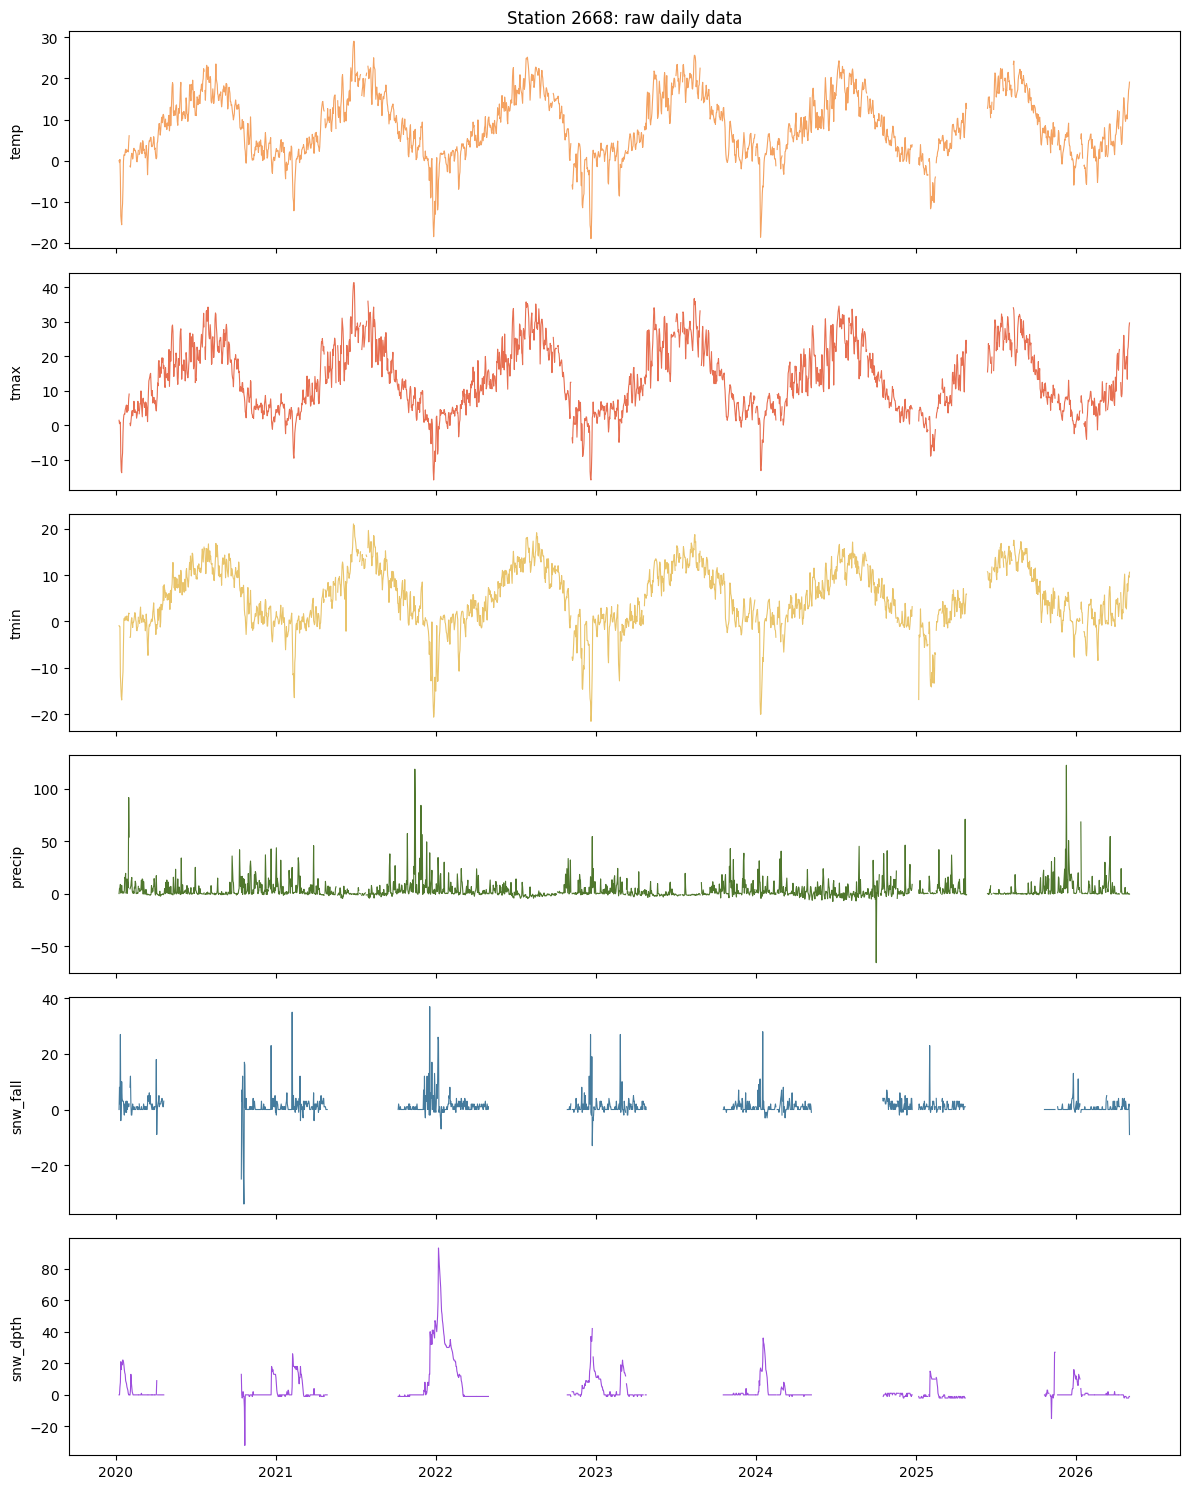

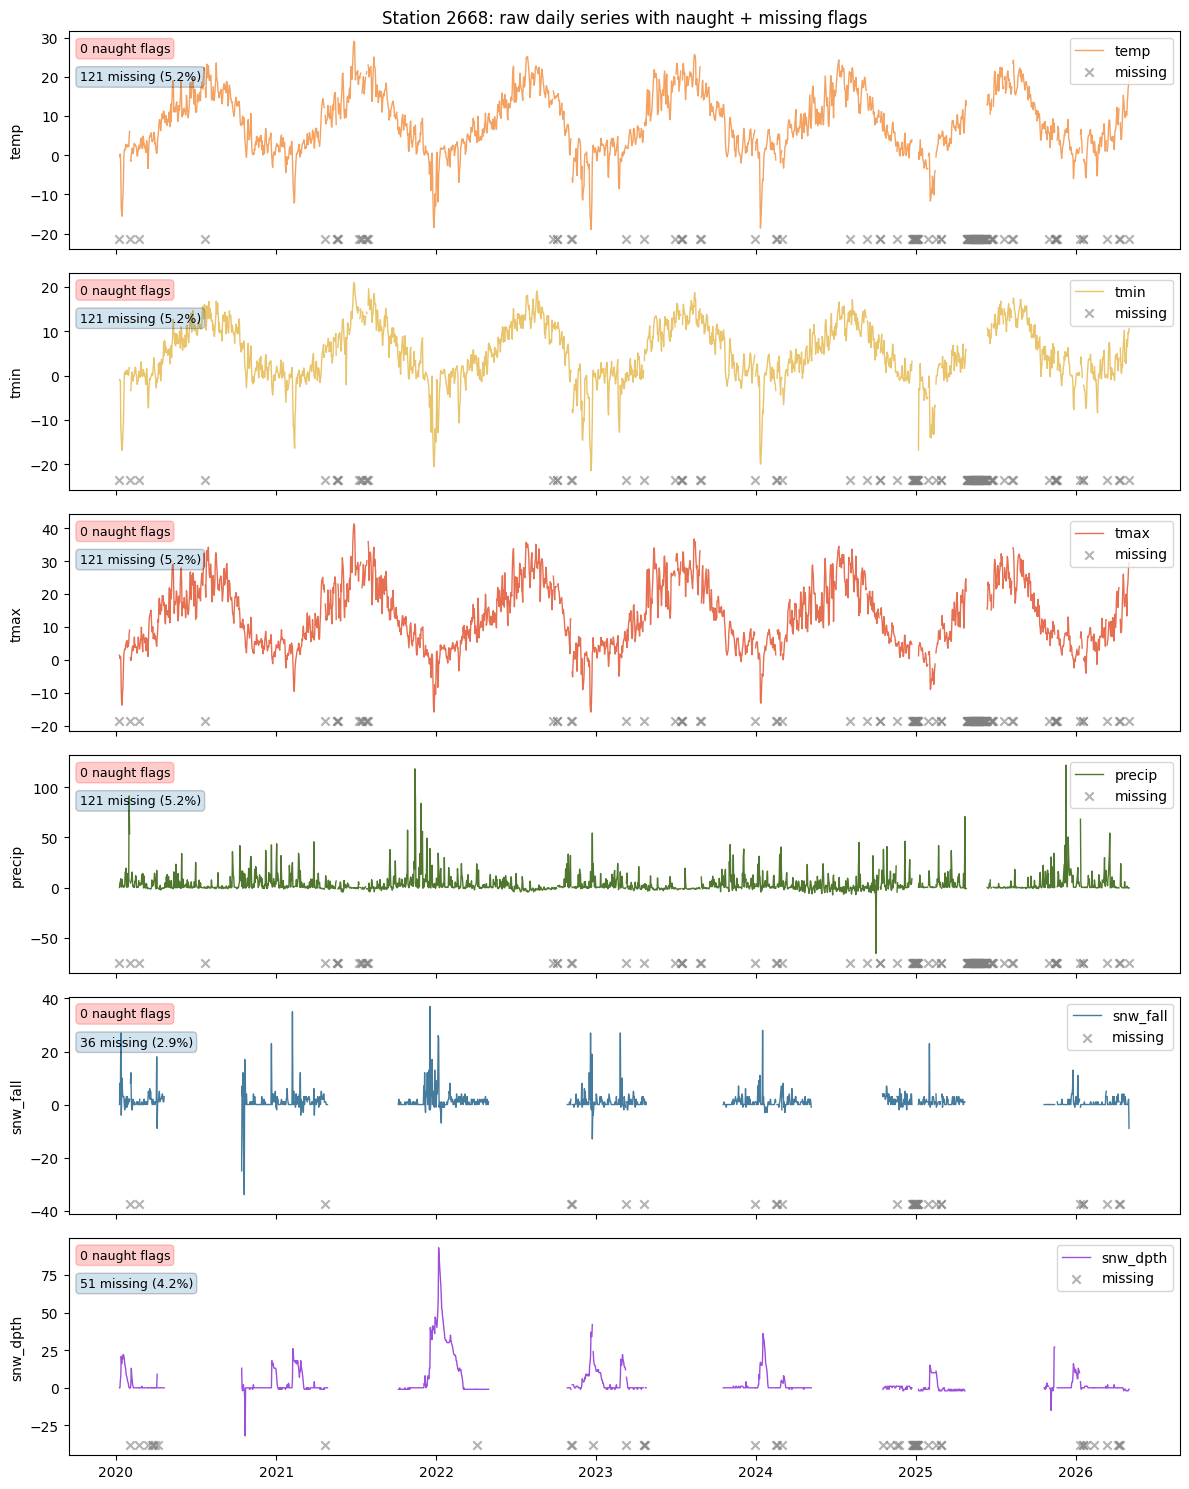

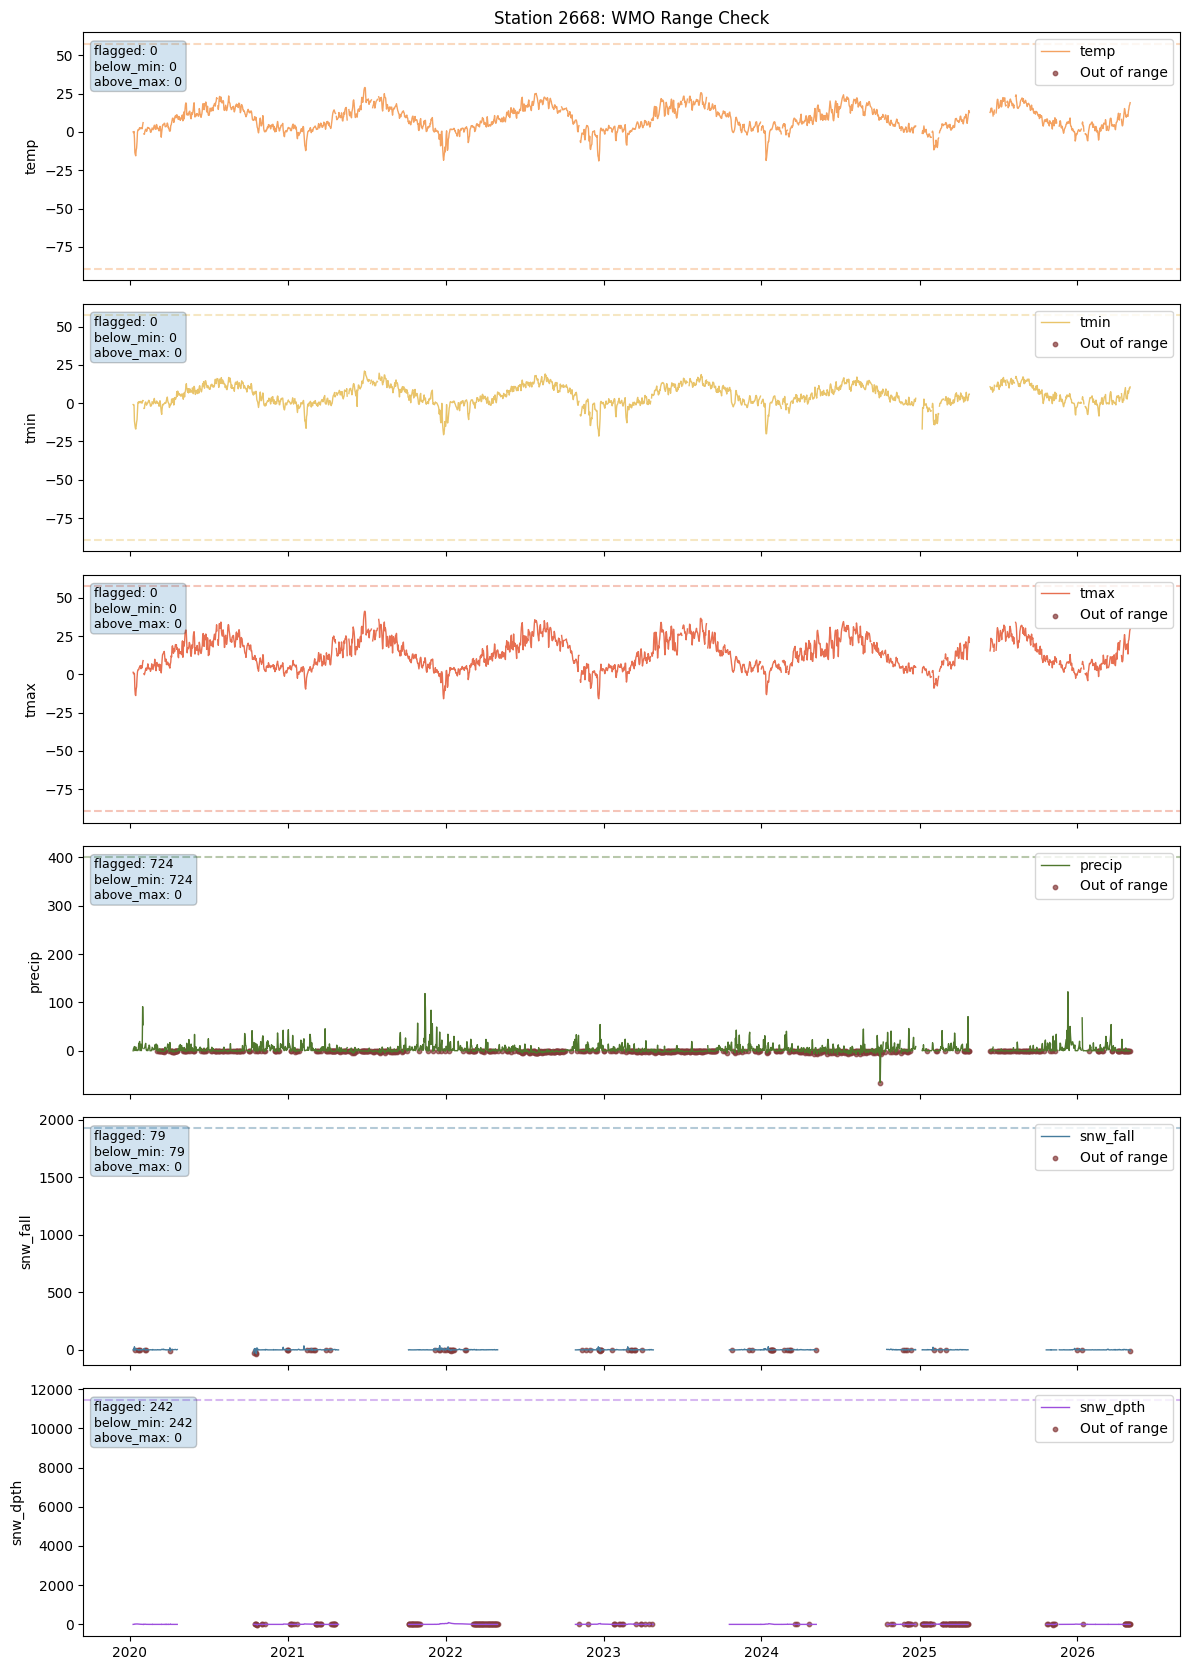

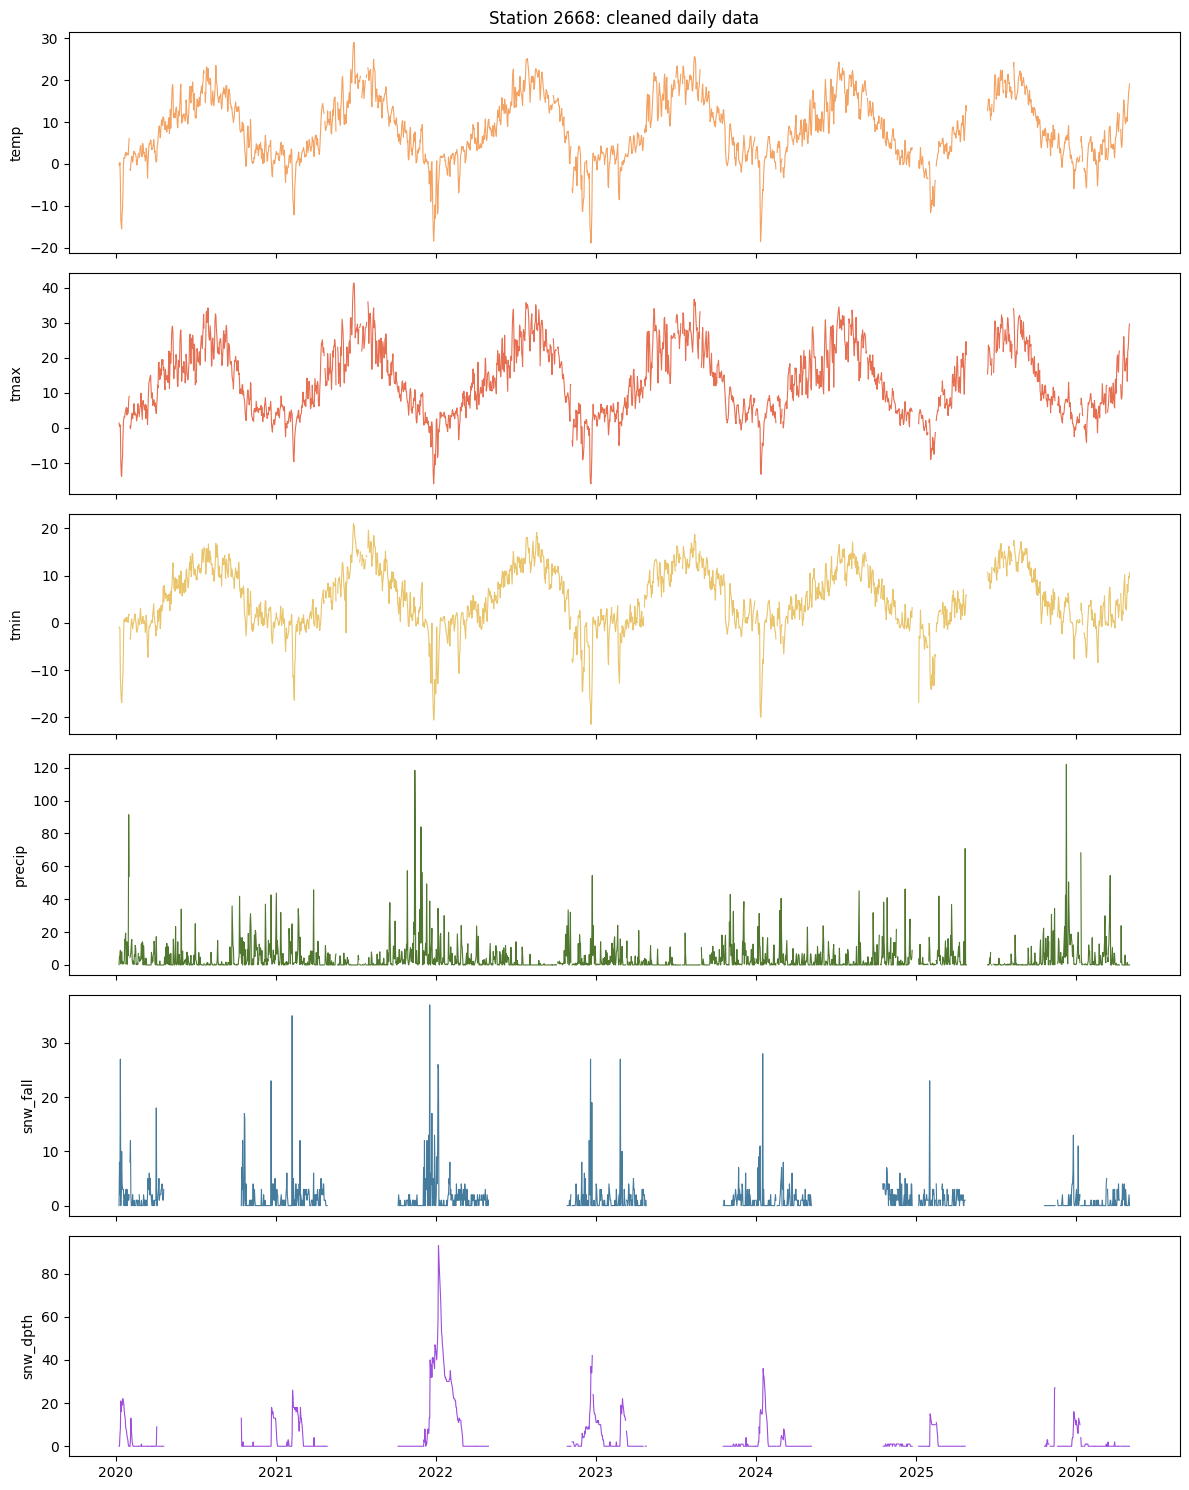

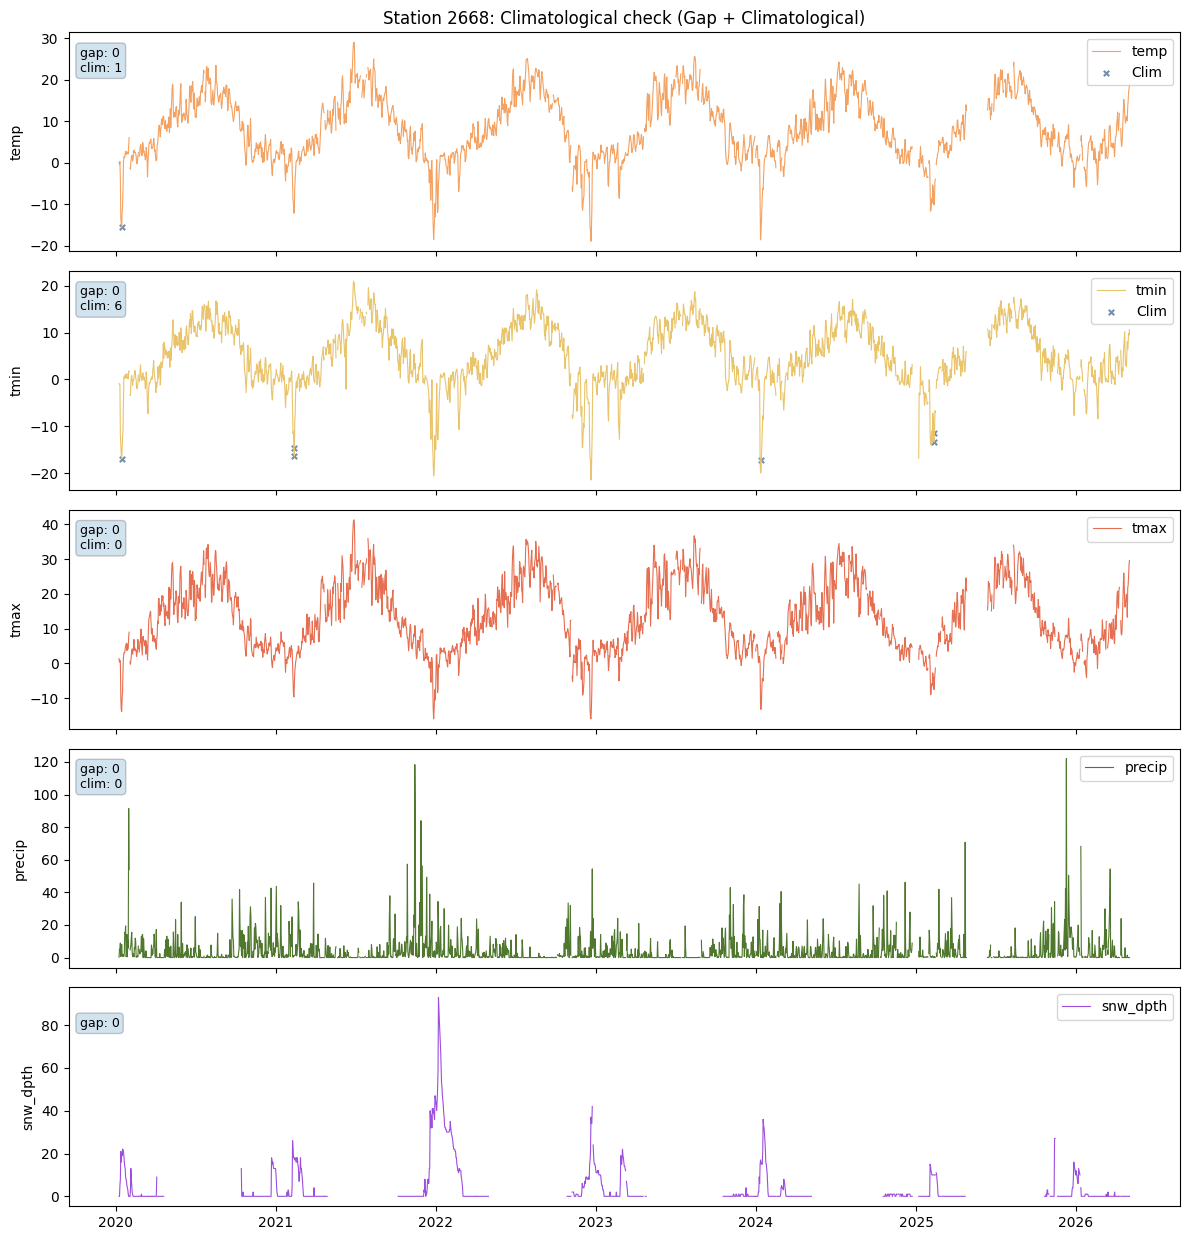

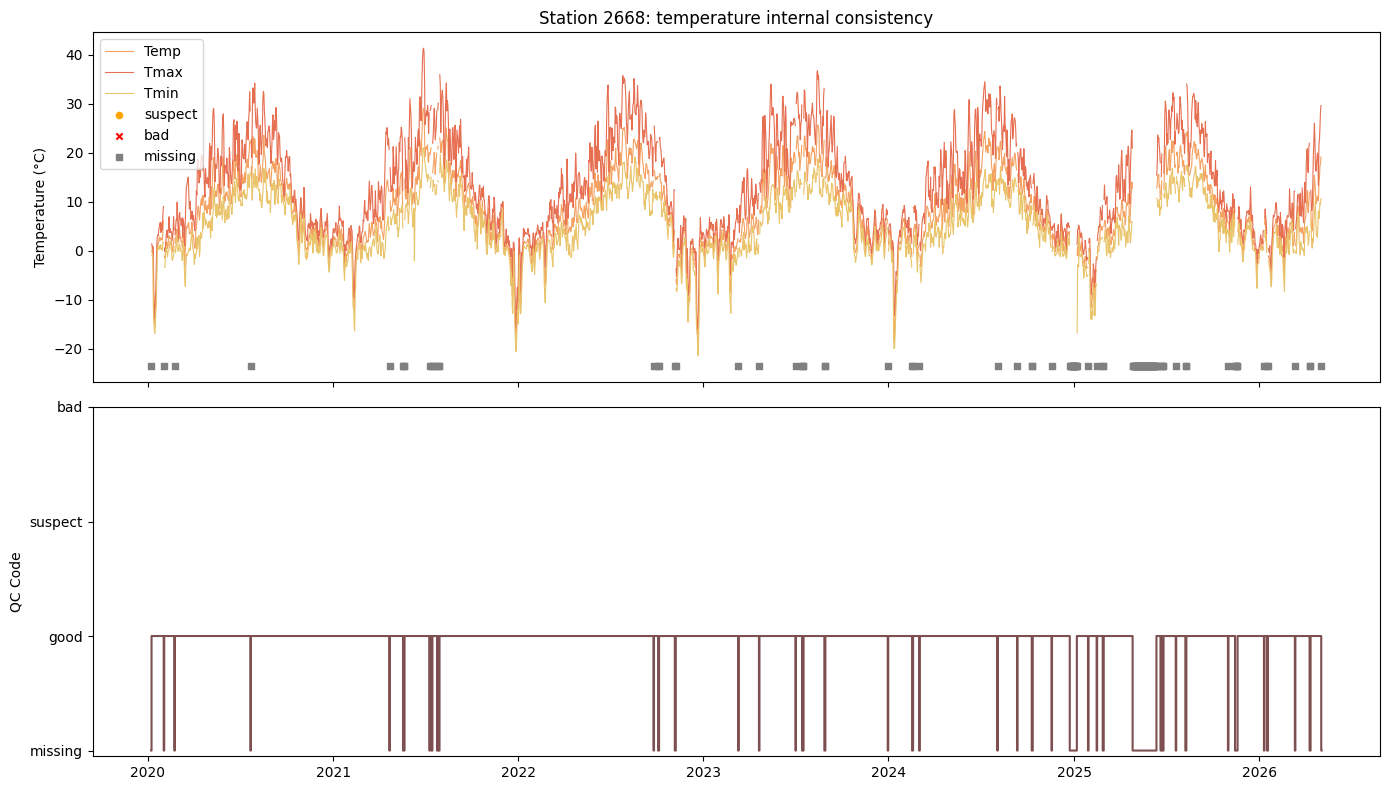

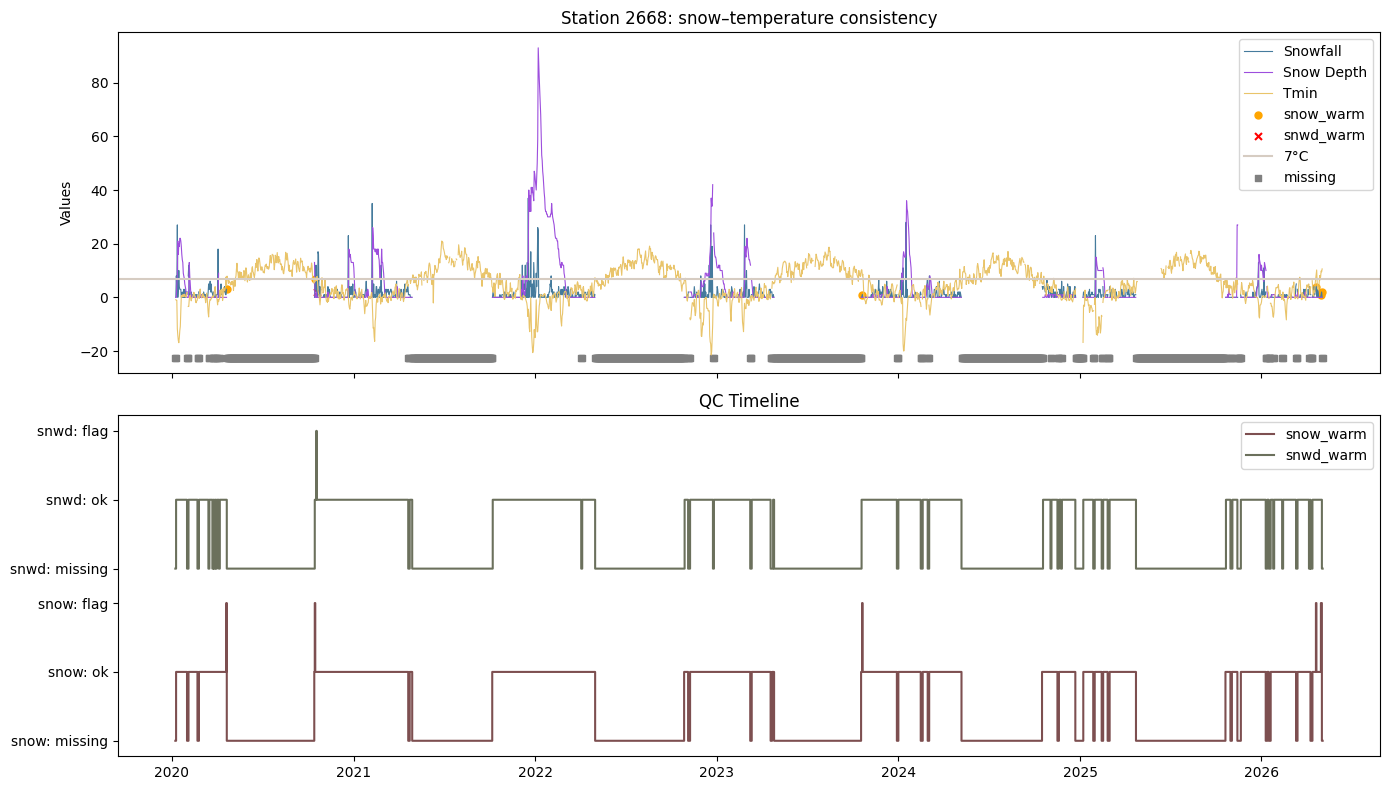

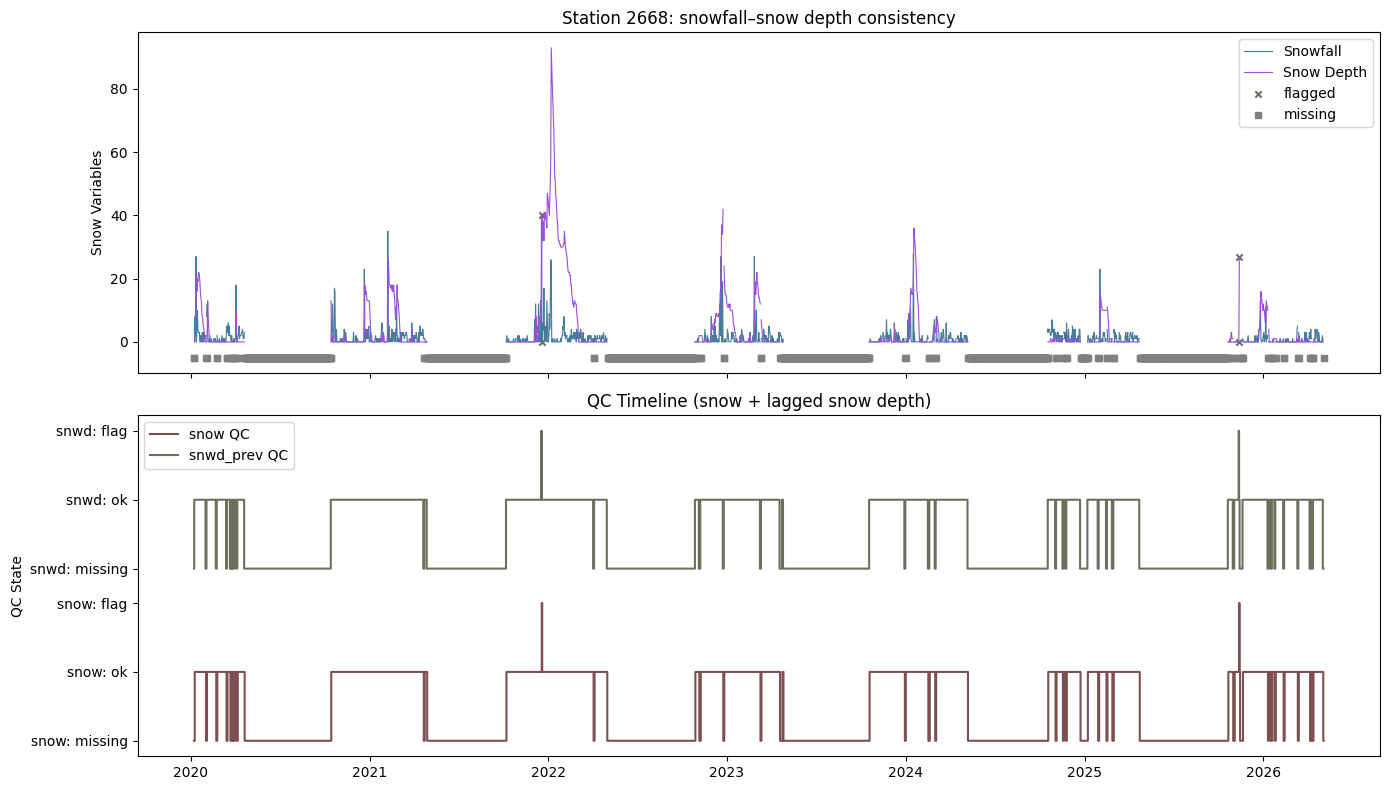

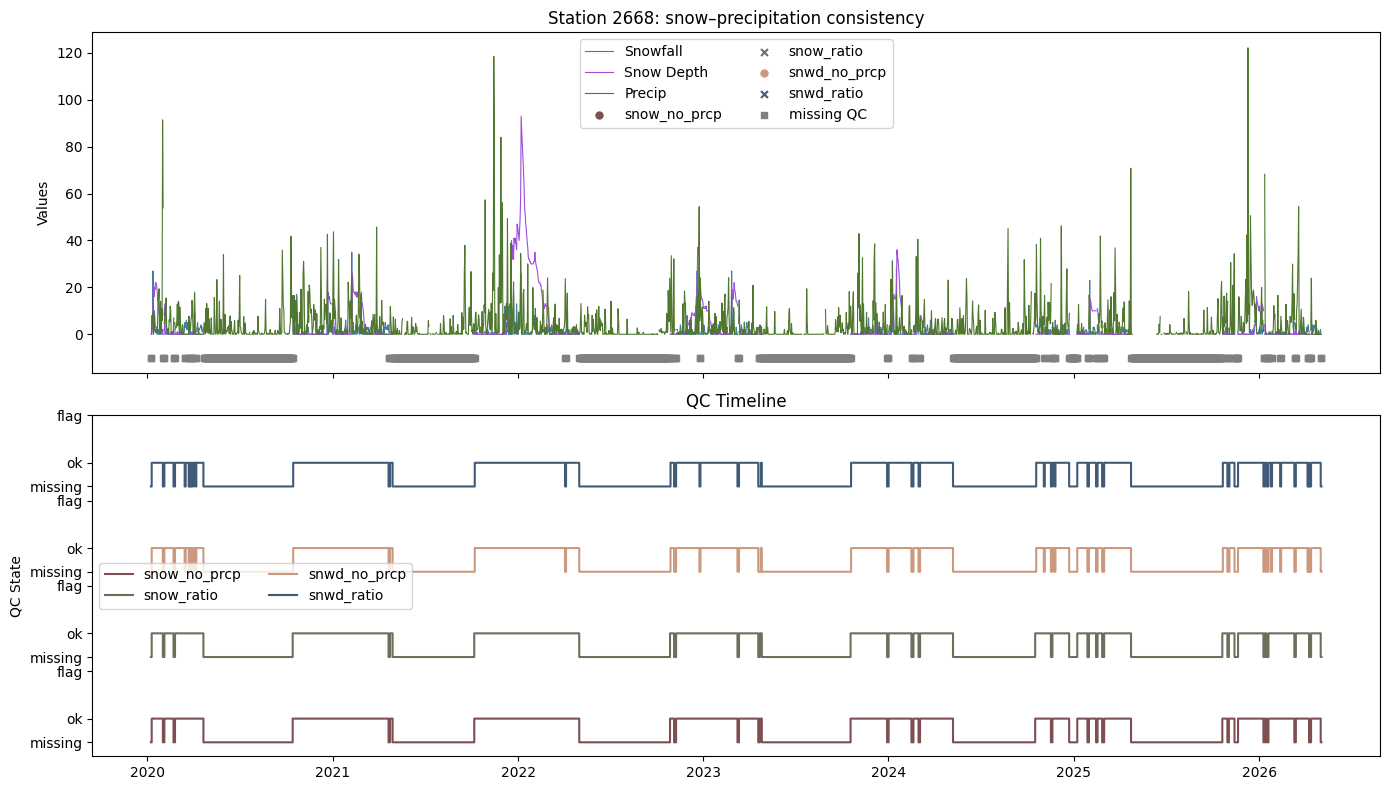

Station 2794
Total days in dataset: 2309

temp: 0 flagged days (0.00%)
  Sample dates: []

tmin: 0 flagged days (0.00%)
  Sample dates: []

tmax: 0 flagged days (0.00%)
  Sample dates: []

precip: 0 flagged days (0.00%)
  Sample dates: []

snw_fall: 3 flagged days (0.13%)
  snow_fall_depth: 3 days
  Sample dates: [Timestamp('2021-11-15 00:00:00'), Timestamp('2024-02-29 00:00:00'), Timestamp('2026-02-18 00:00:00')]

snw_dpth: 3 flagged days (0.13%)
  snow_fall_depth: 3 days
  Sample dates: [Timestamp('2021-11-15 00:00:00'), Timestamp('2024-02-29 00:00:00'), Timestamp('2026-02-18 00:00:00')]

TEMPORAL COVERAGE ANALYSIS

Dataset period: 2020-01-08 to 2026-05-04
Total span: 2309 days (~6.32 years)

Years covered: 2020 to 2026 (7 years)

✅ Continuous years: All years from 2020 to 2026 are covered

Large gaps check (> 1 year = 365 days):
----------------------------------------------------------------------
temp: ✅ No large gaps (all gaps < 1 year)
tmin: ✅ No large gaps (all gaps < 1 year)
t

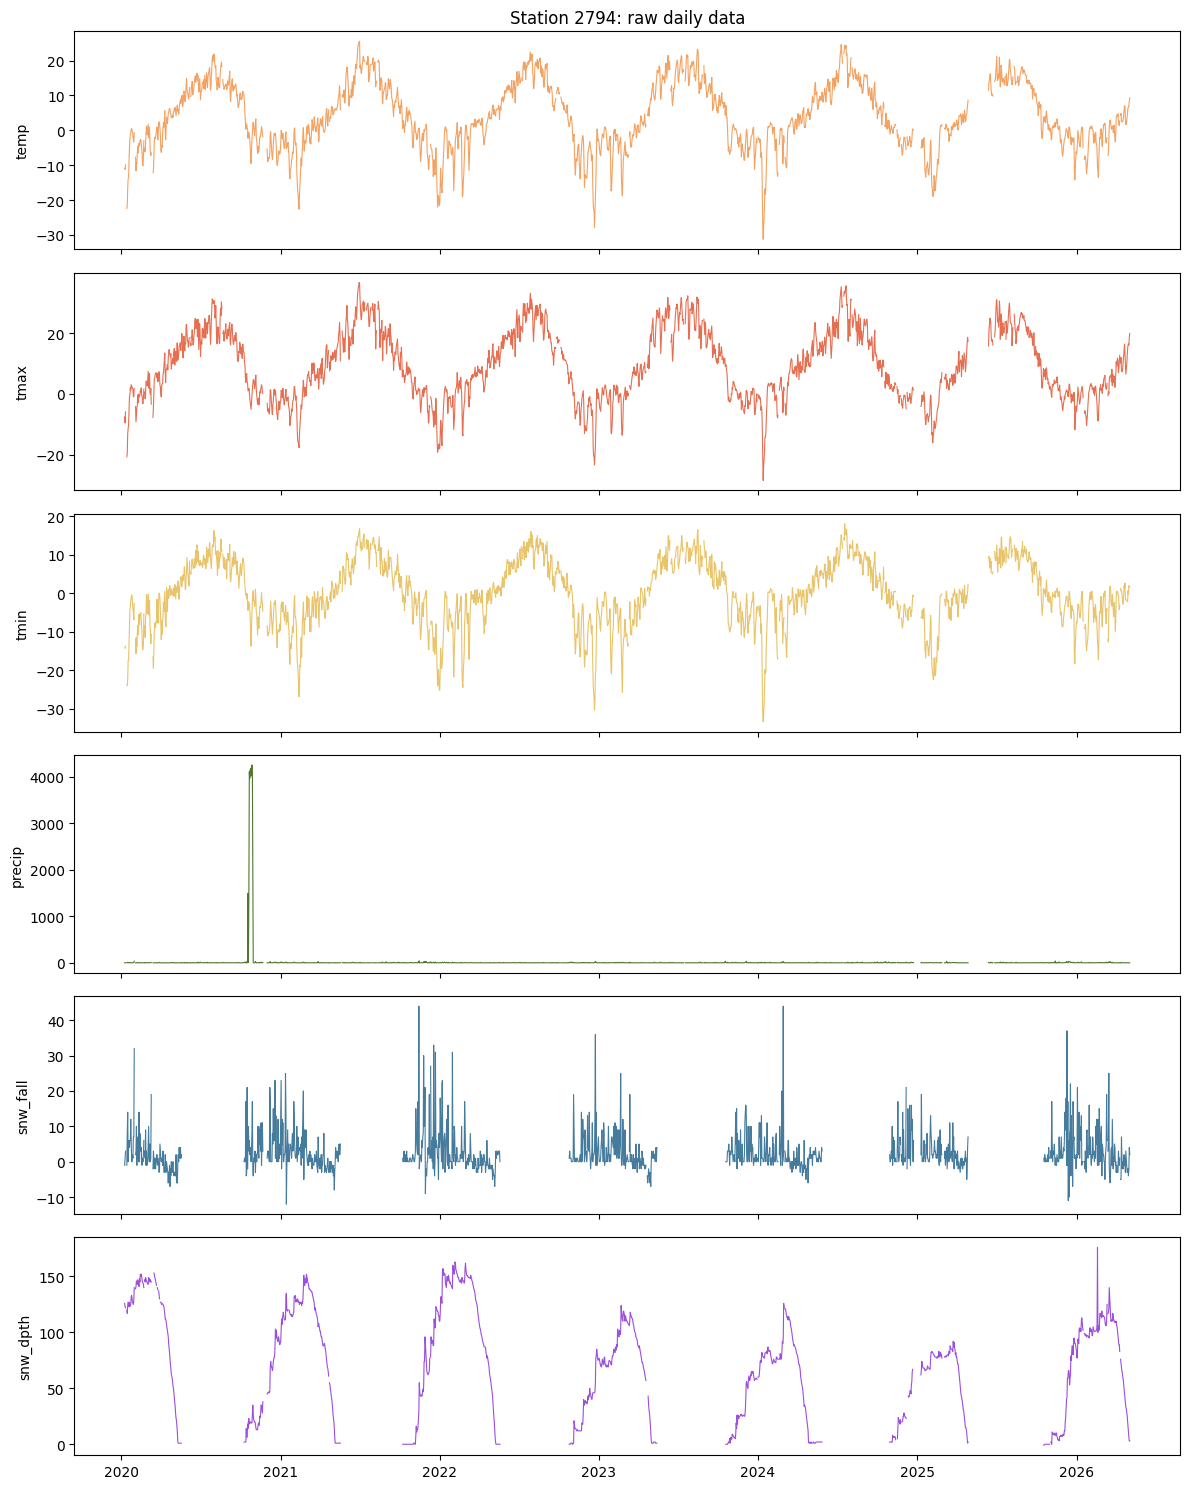

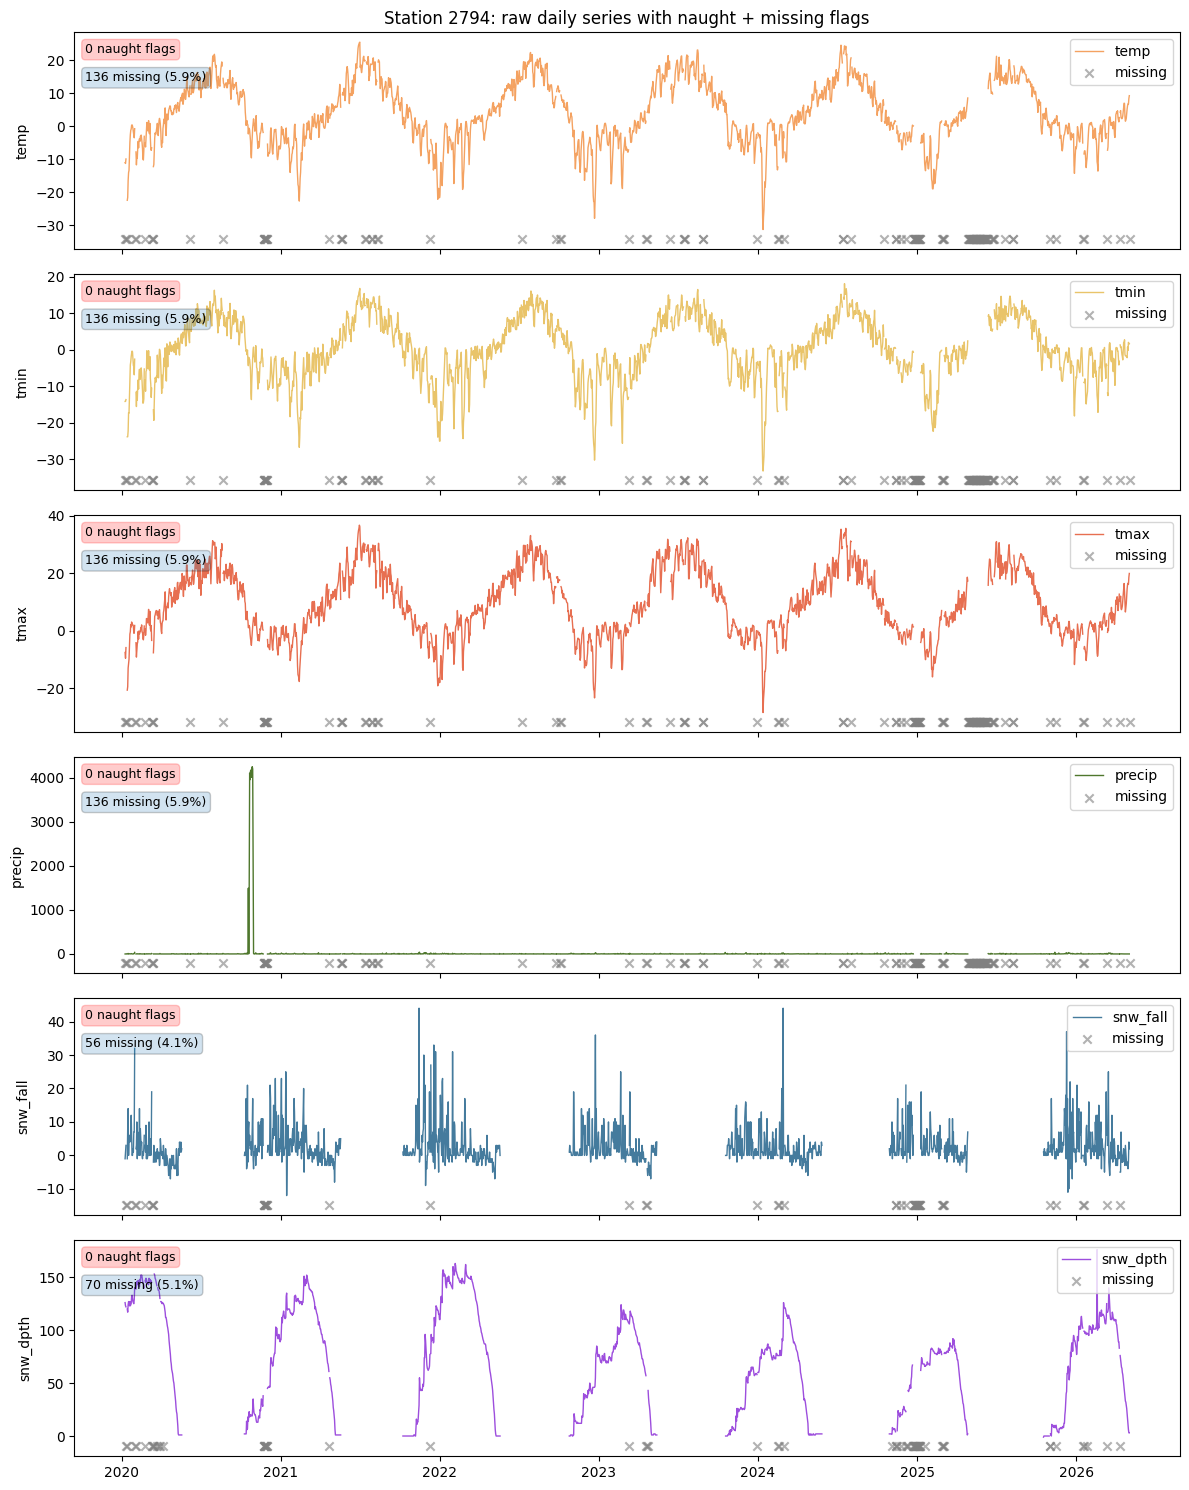

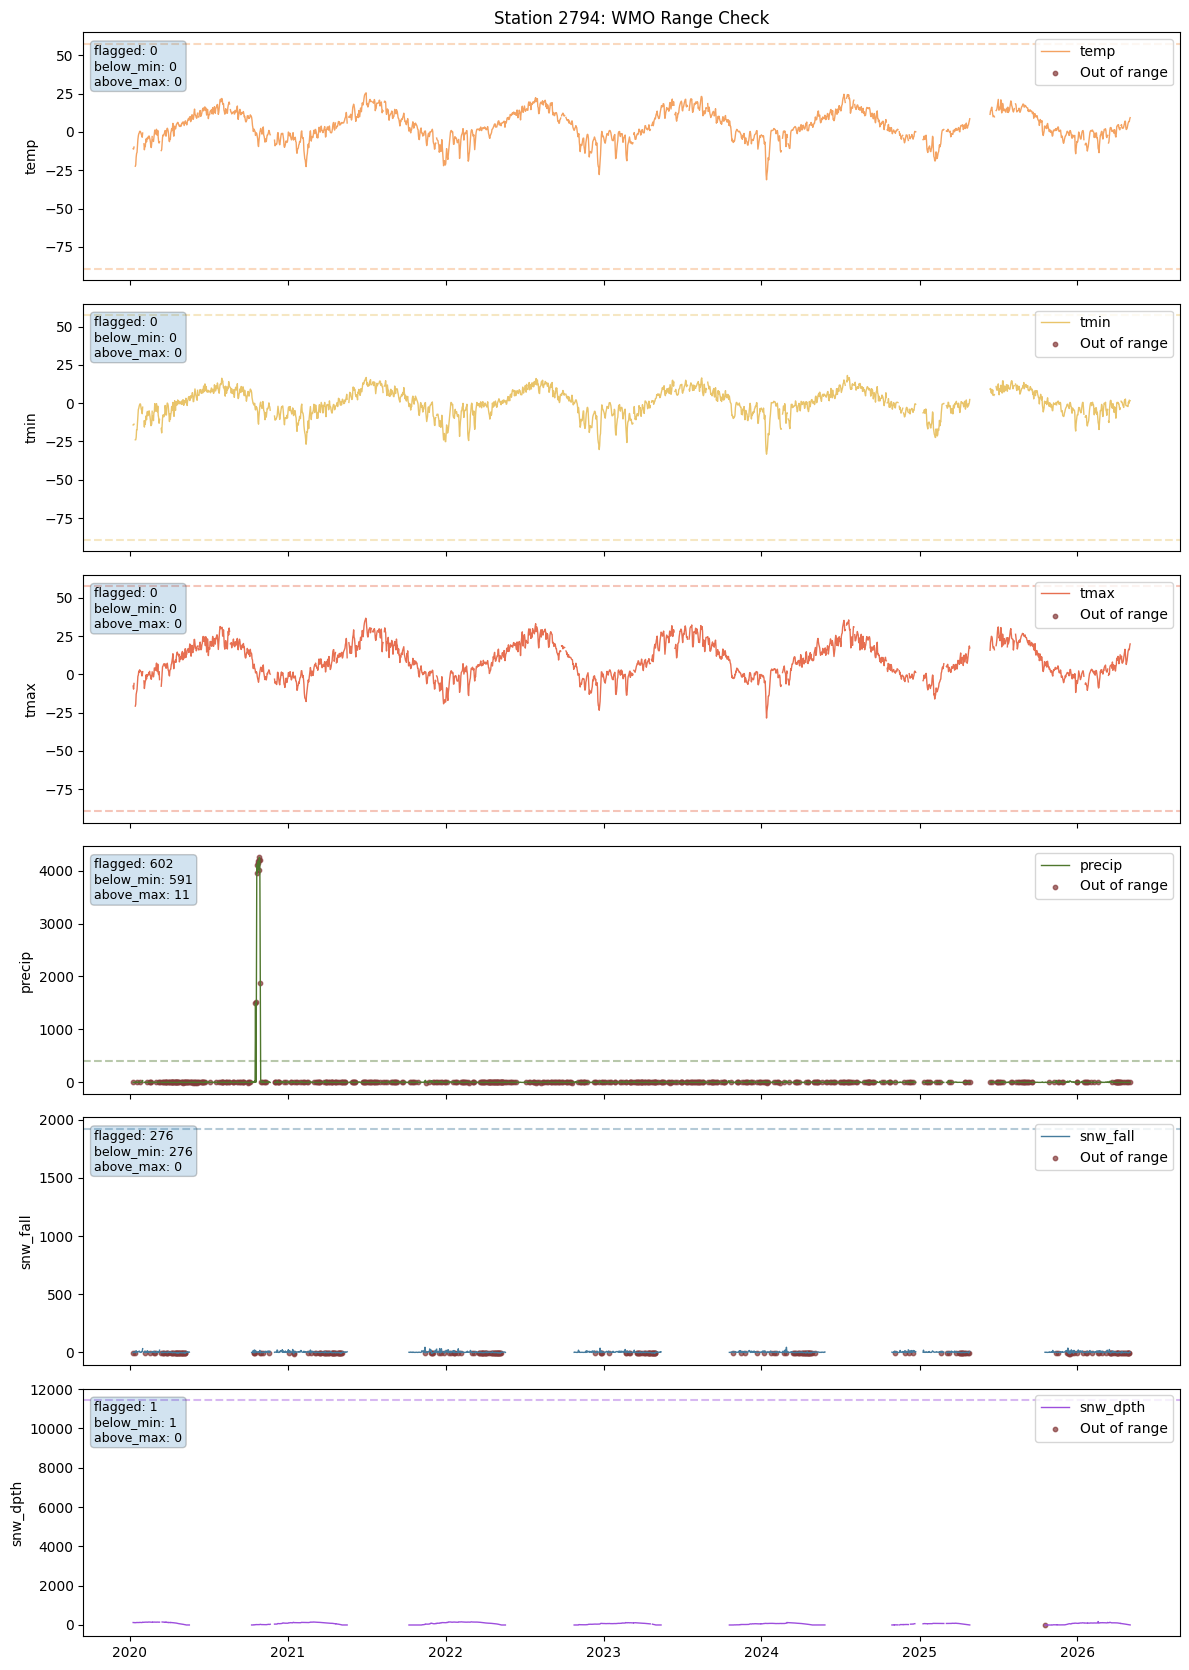

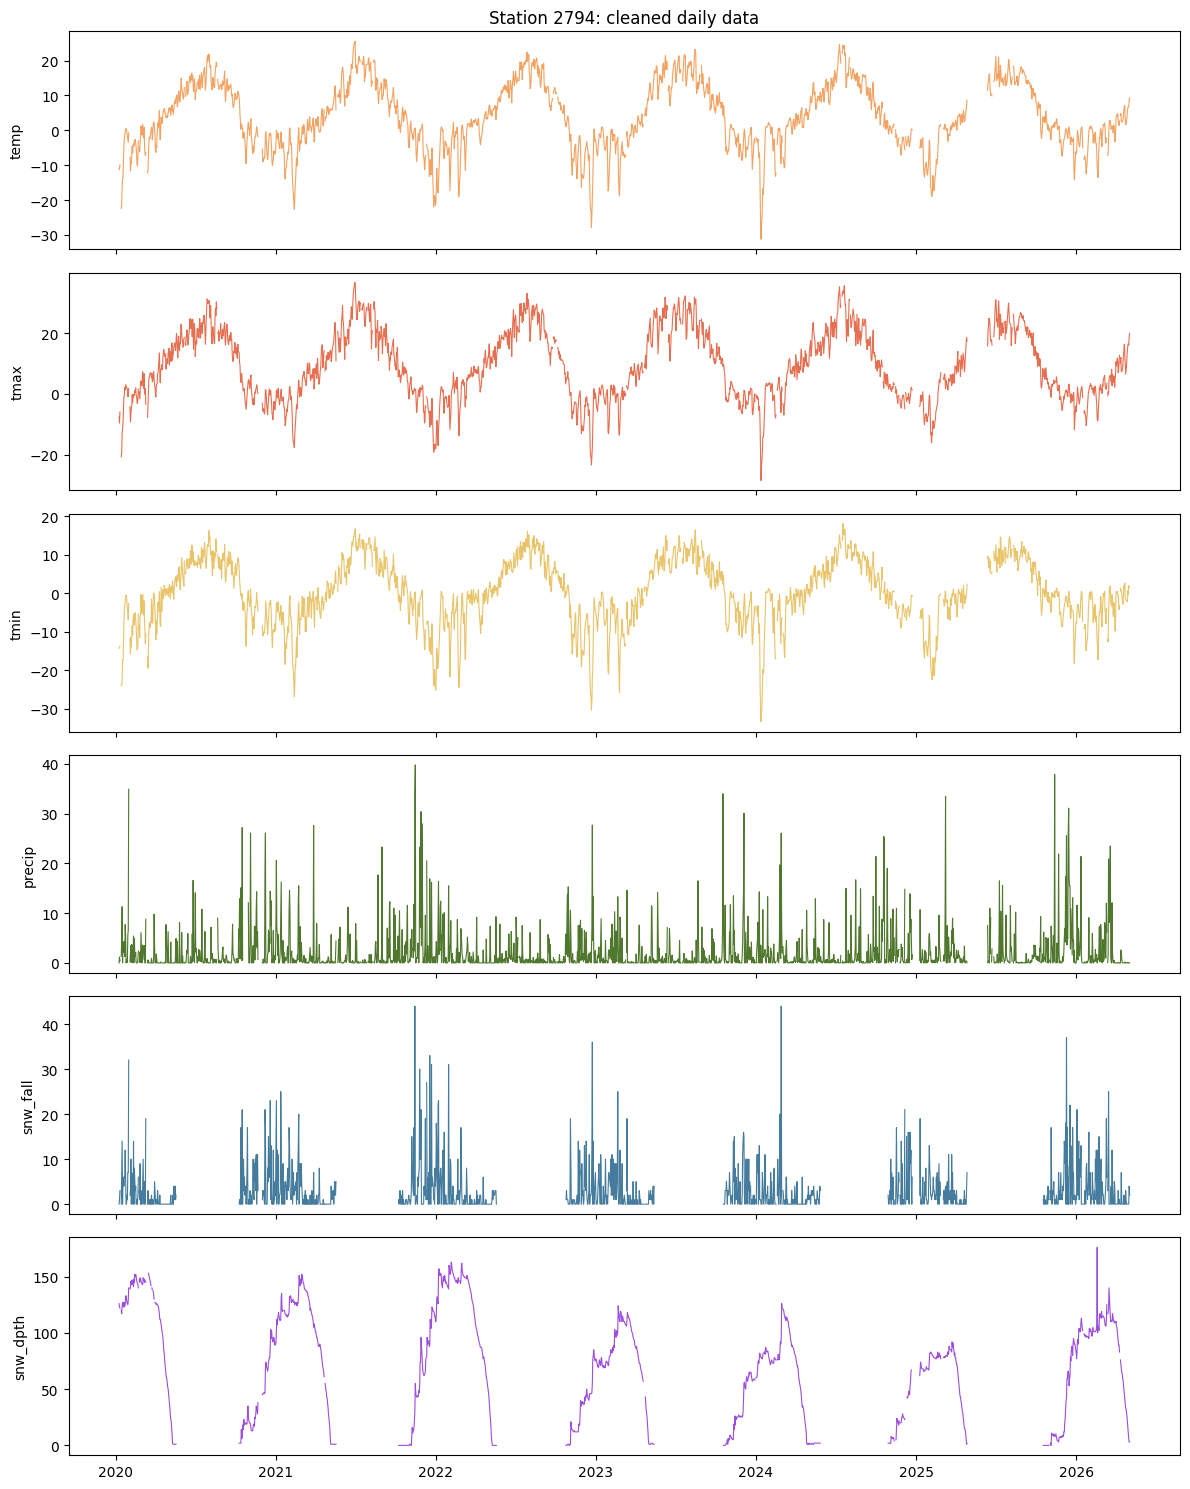

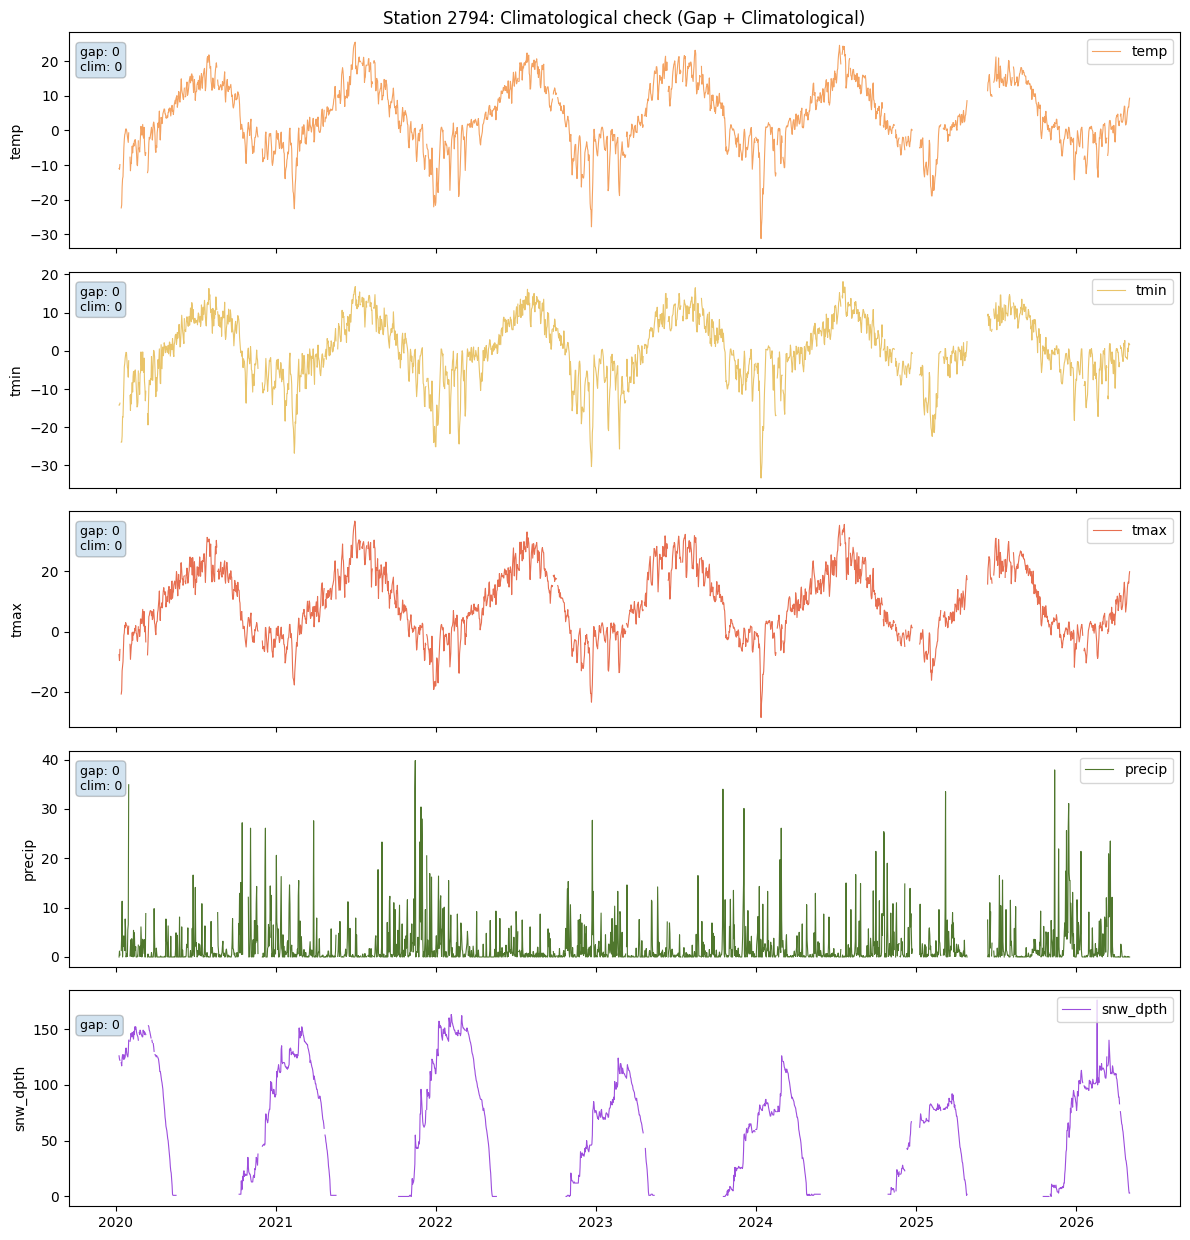

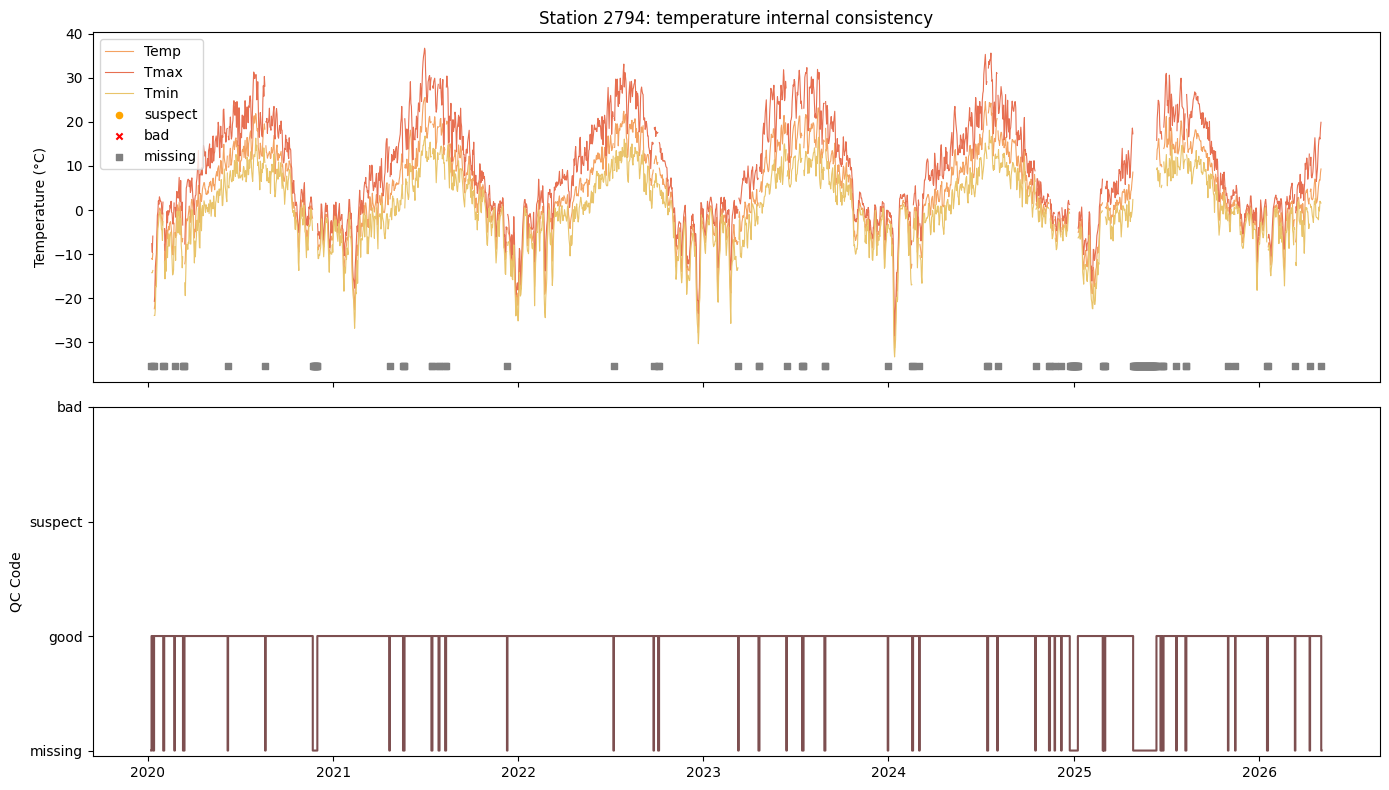

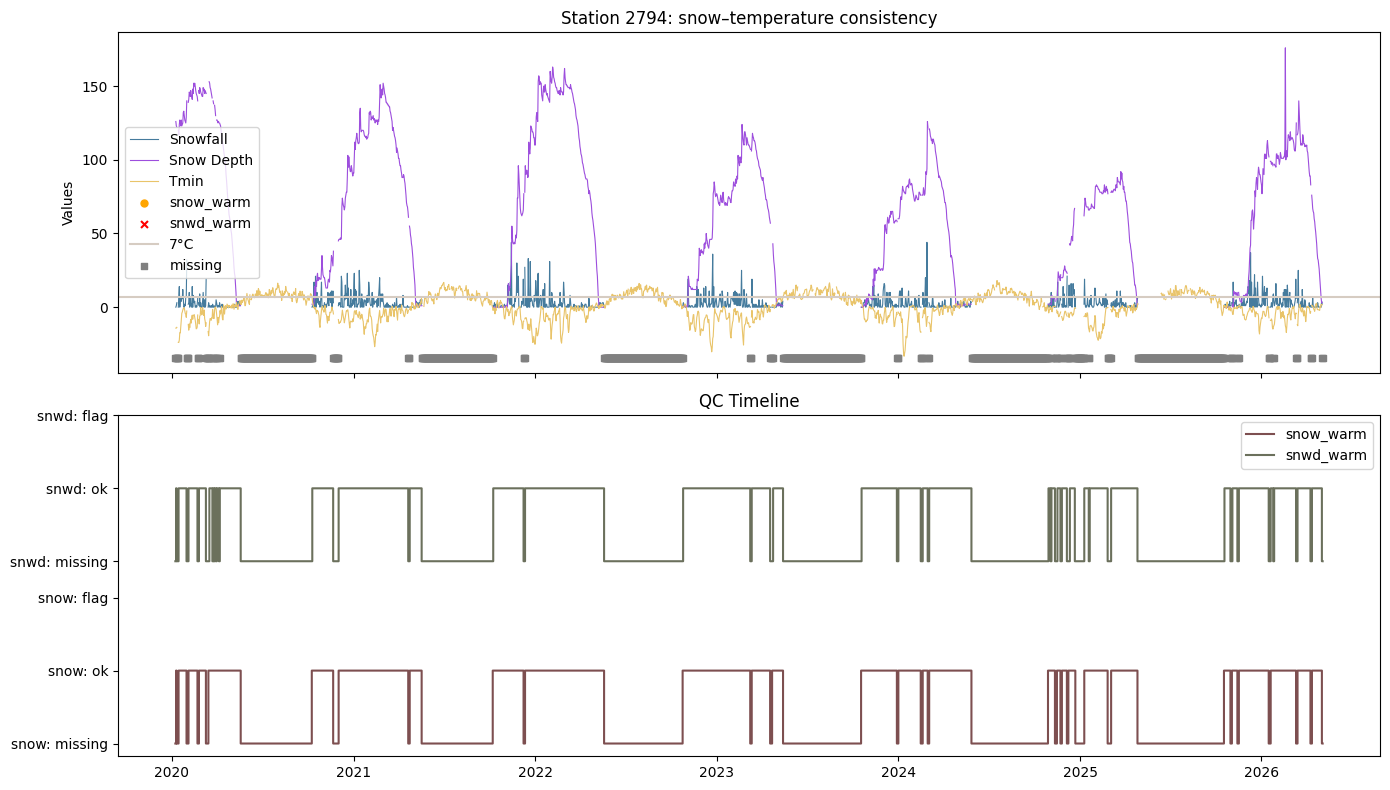

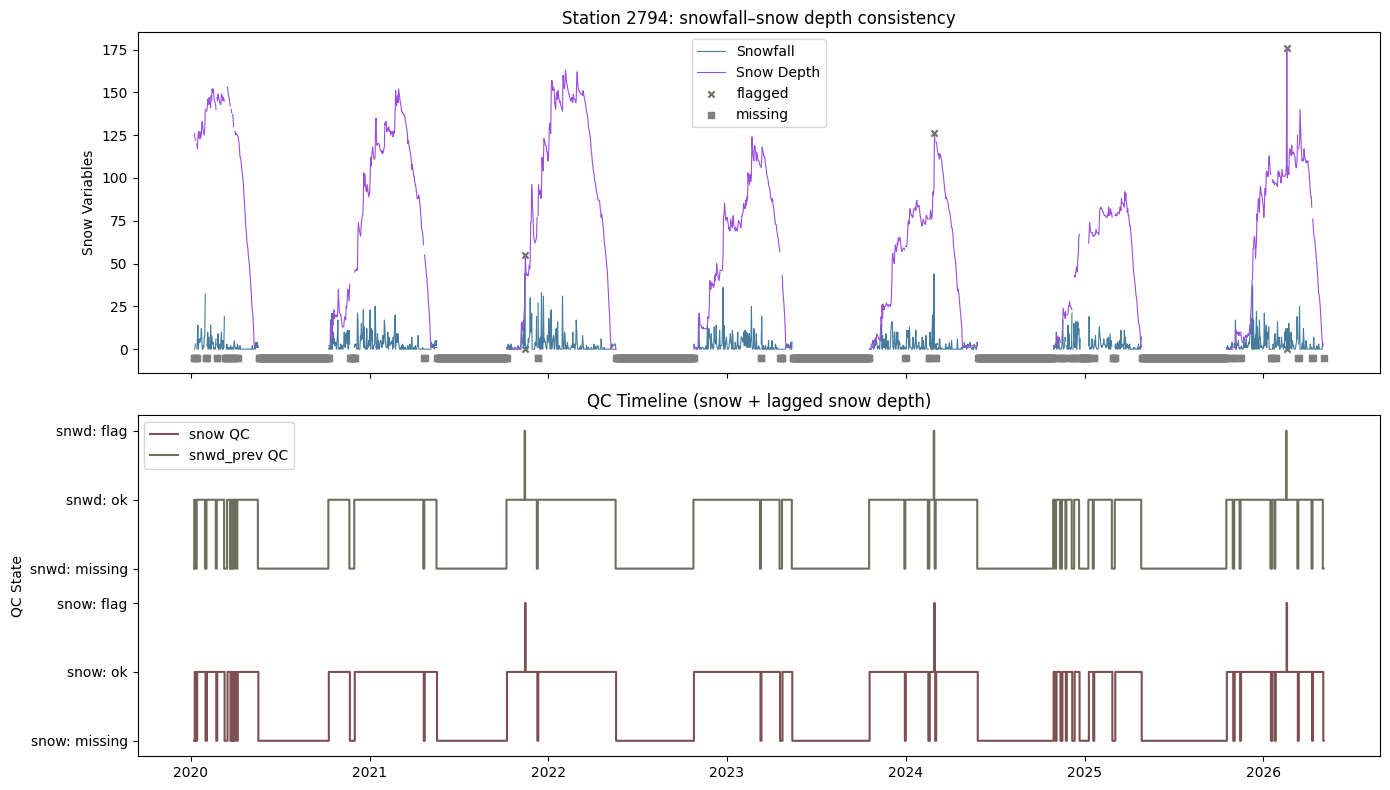

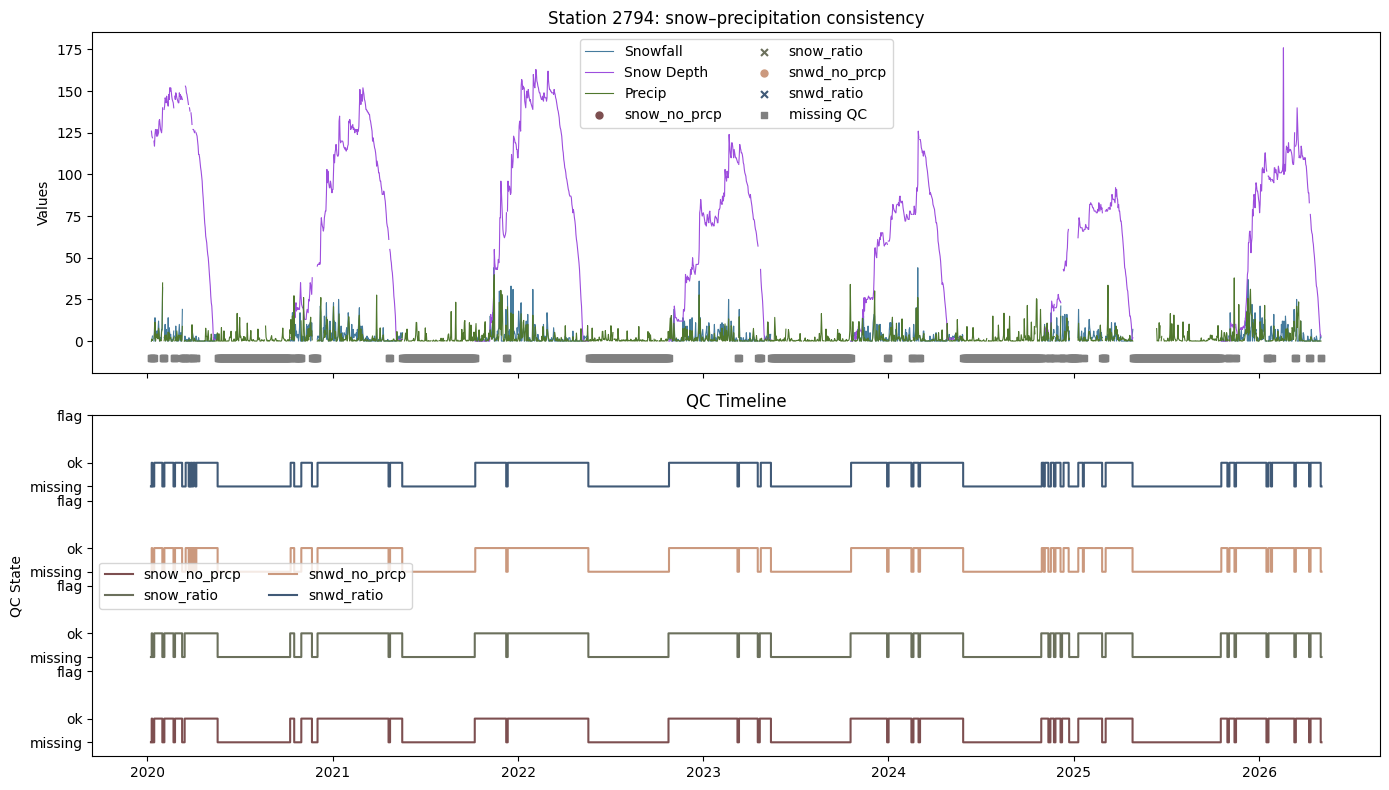

Station 2955
Total days in dataset: 2309

temp: 0 flagged days (0.00%)
  Sample dates: []

tmin: 0 flagged days (0.00%)
  Sample dates: []

tmax: 0 flagged days (0.00%)
  Sample dates: []

precip: 0 flagged days (0.00%)
  Sample dates: []

snw_fall: 29 flagged days (1.26%)
  value_streaks: 26 days
  snow_temp_warm: 2 days
  snow_fall_depth: 1 days
  Sample dates: [Timestamp('2020-01-16 00:00:00'), Timestamp('2020-10-17 00:00:00'), Timestamp('2023-01-01 00:00:00'), Timestamp('2023-01-02 00:00:00'), Timestamp('2023-01-03 00:00:00')]

snw_dpth: 1 flagged days (0.04%)
  snow_fall_depth: 1 days
  Sample dates: [Timestamp('2020-01-16 00:00:00')]

TEMPORAL COVERAGE ANALYSIS

Dataset period: 2020-01-08 to 2026-05-04
Total span: 2309 days (~6.32 years)

Years covered: 2020 to 2026 (7 years)

✅ Continuous years: All years from 2020 to 2026 are covered

Large gaps check (> 1 year = 365 days):
----------------------------------------------------------------------
temp: ✅ No large gaps (all gaps < 

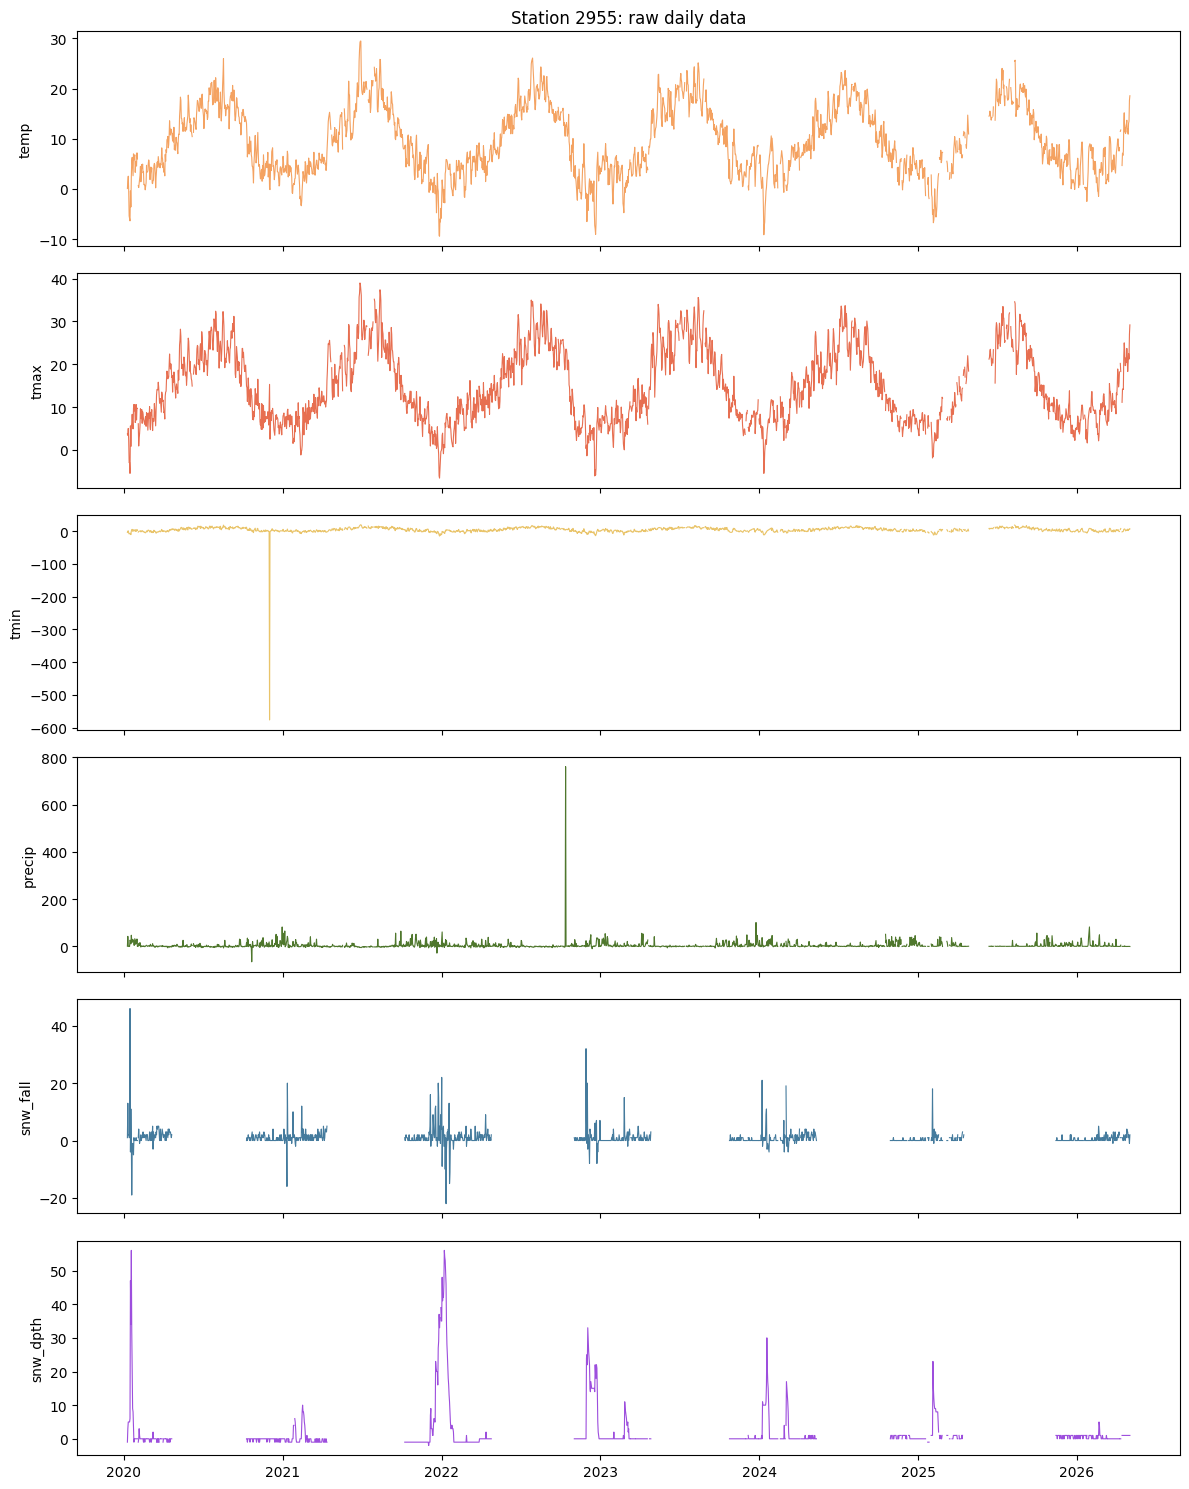

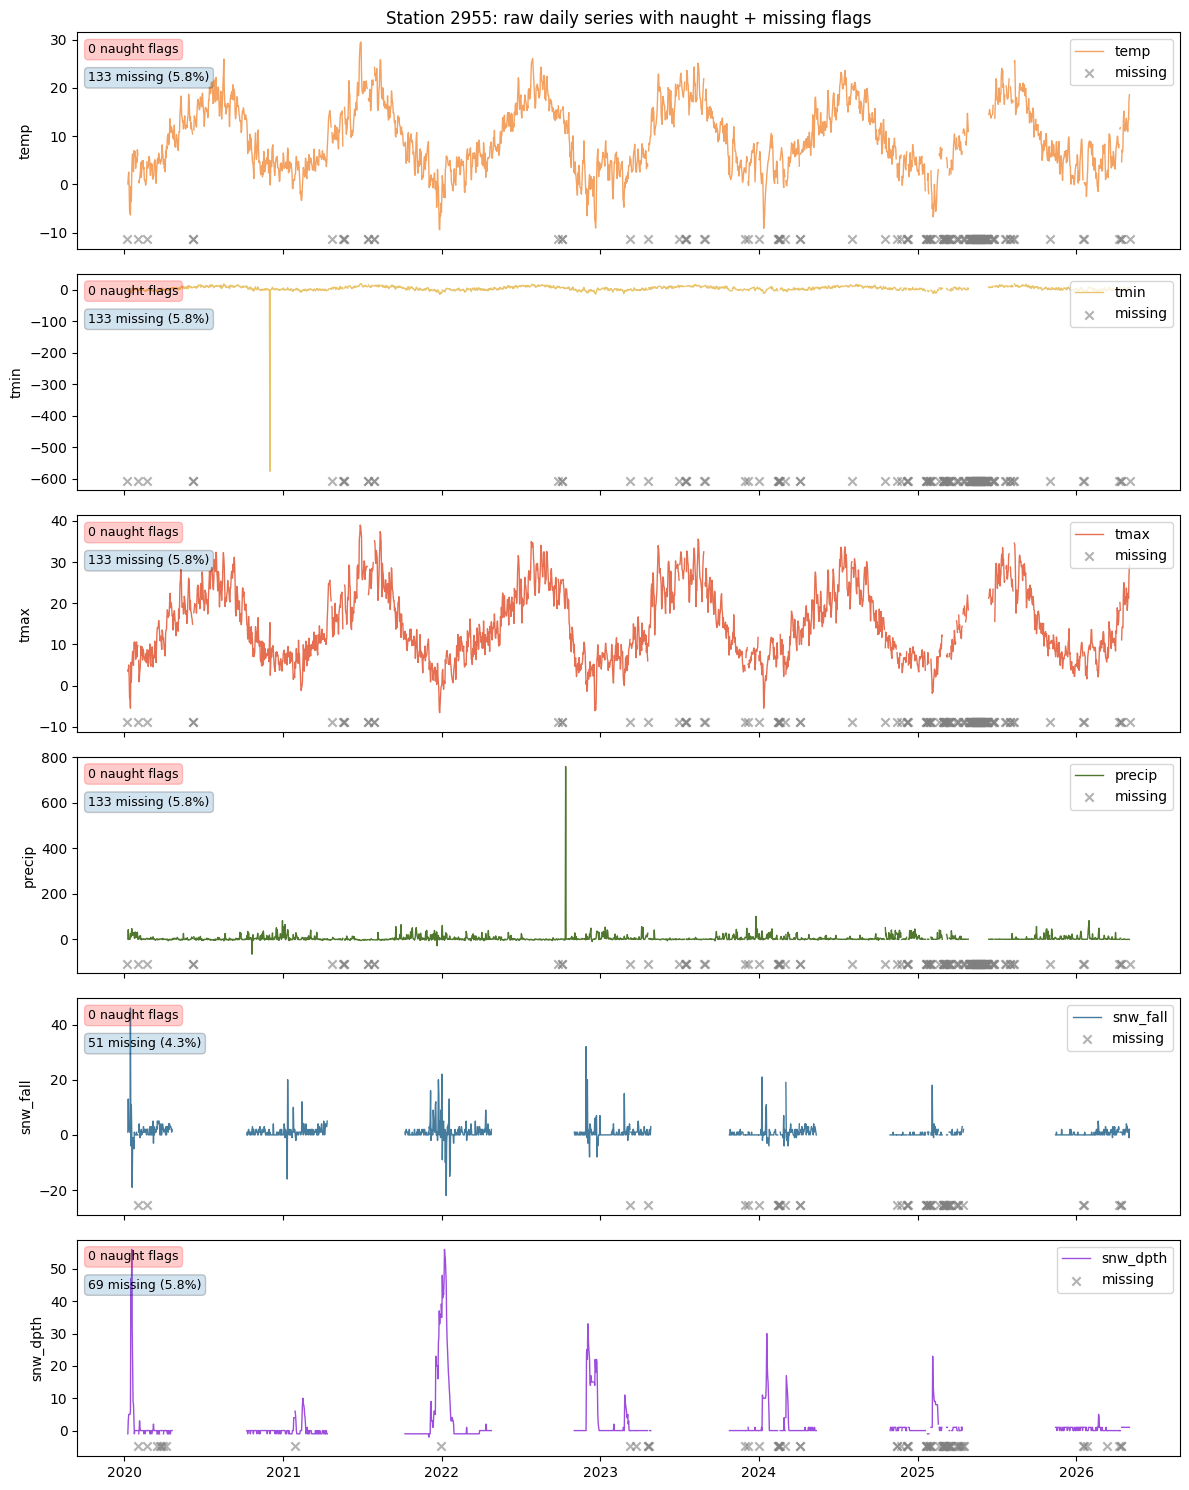

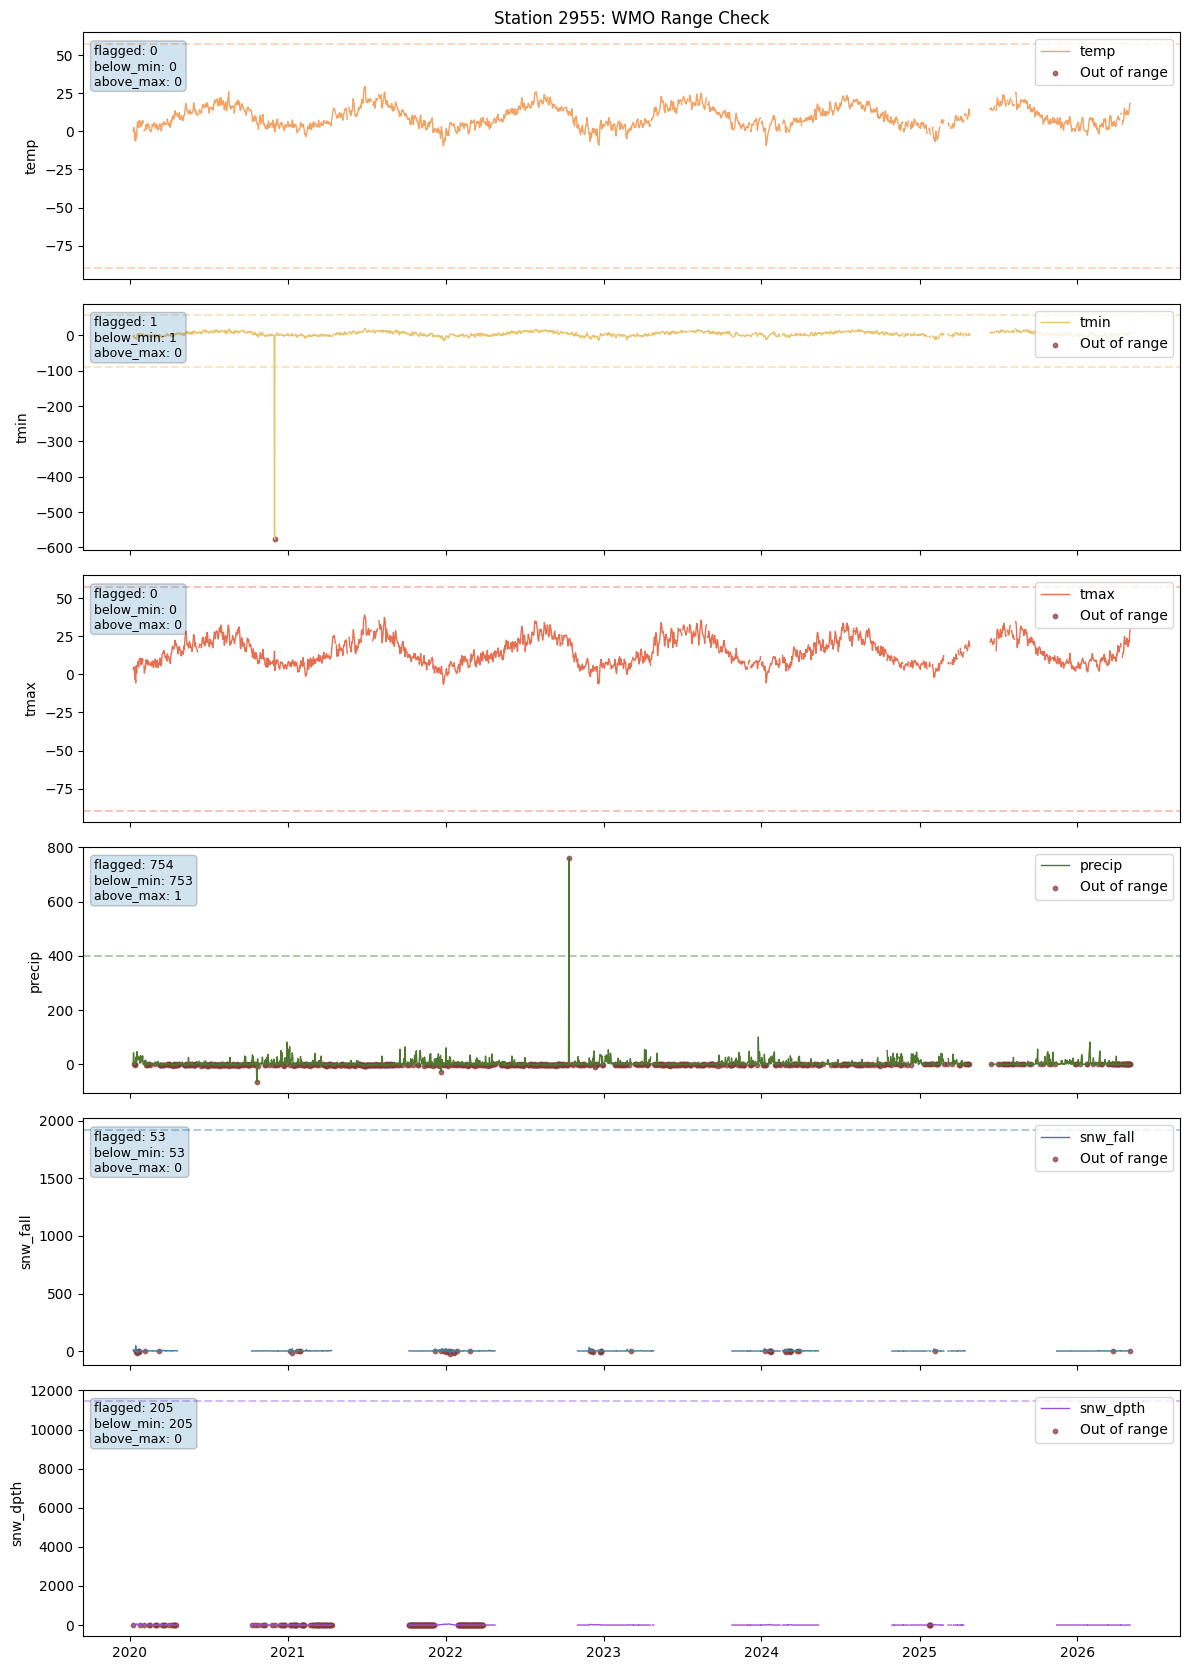

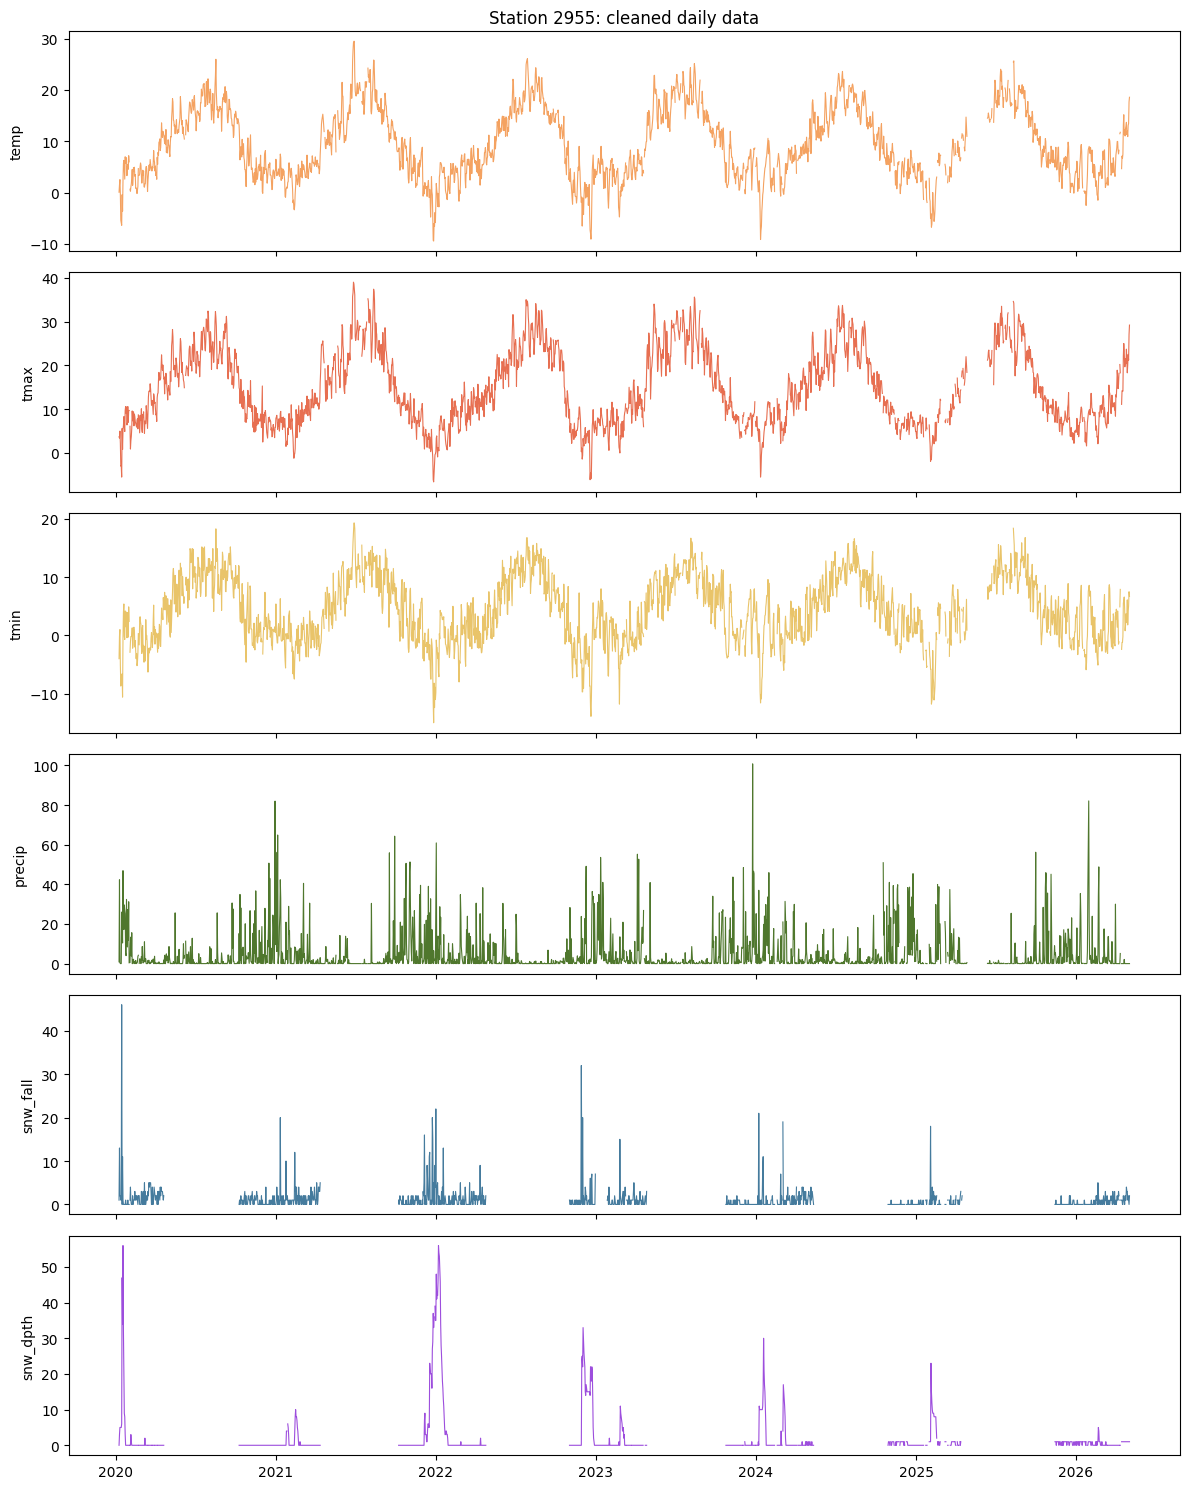

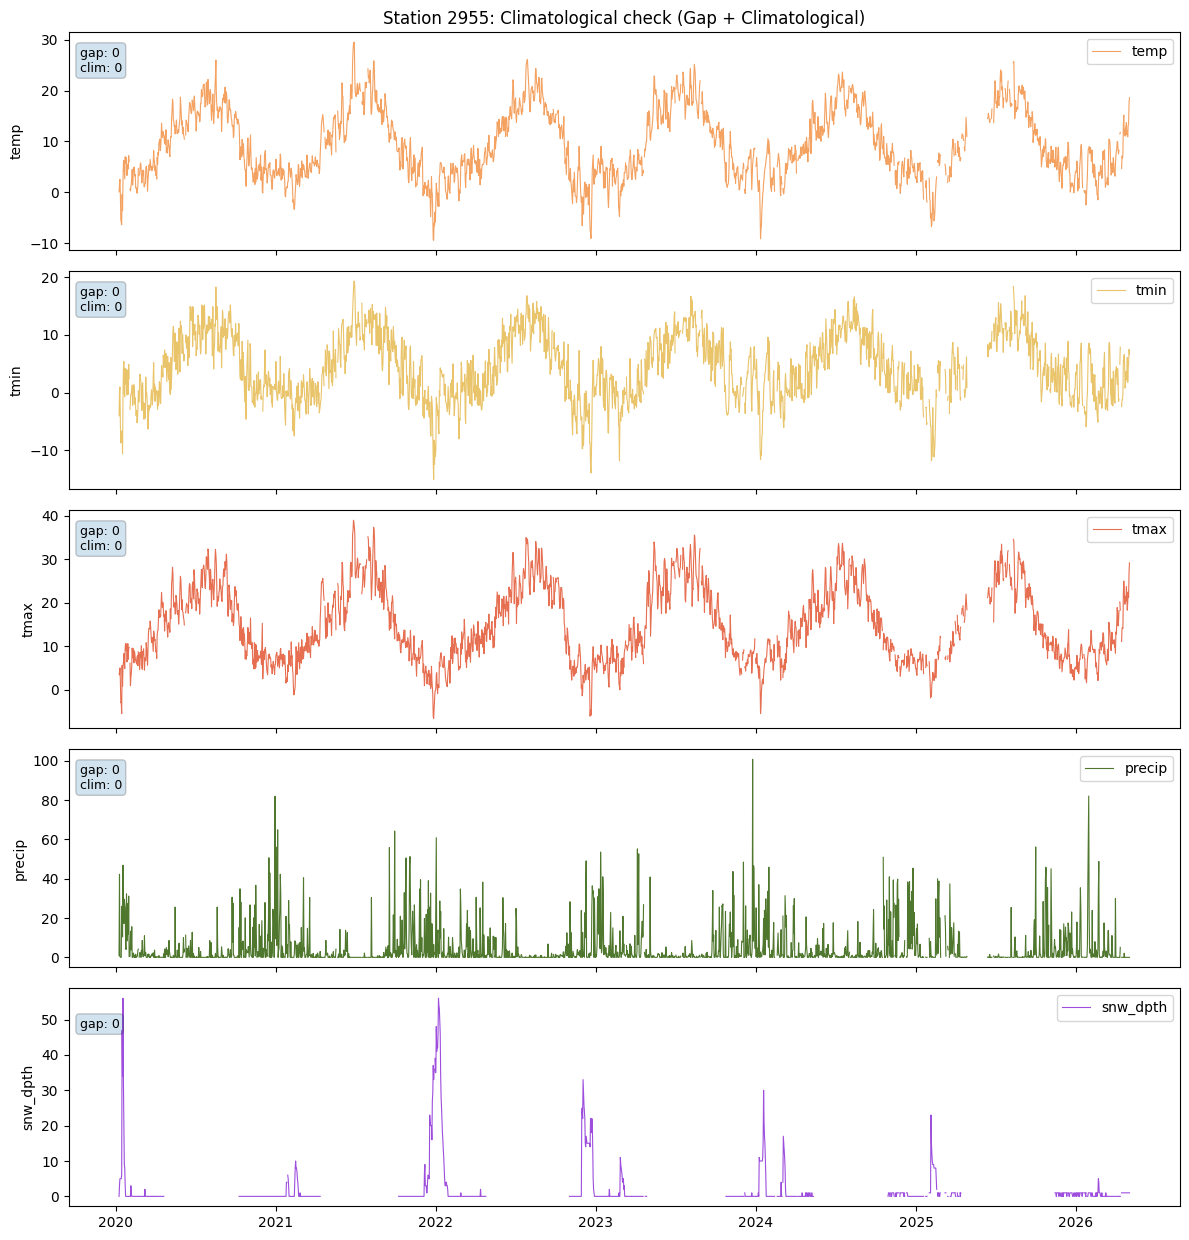

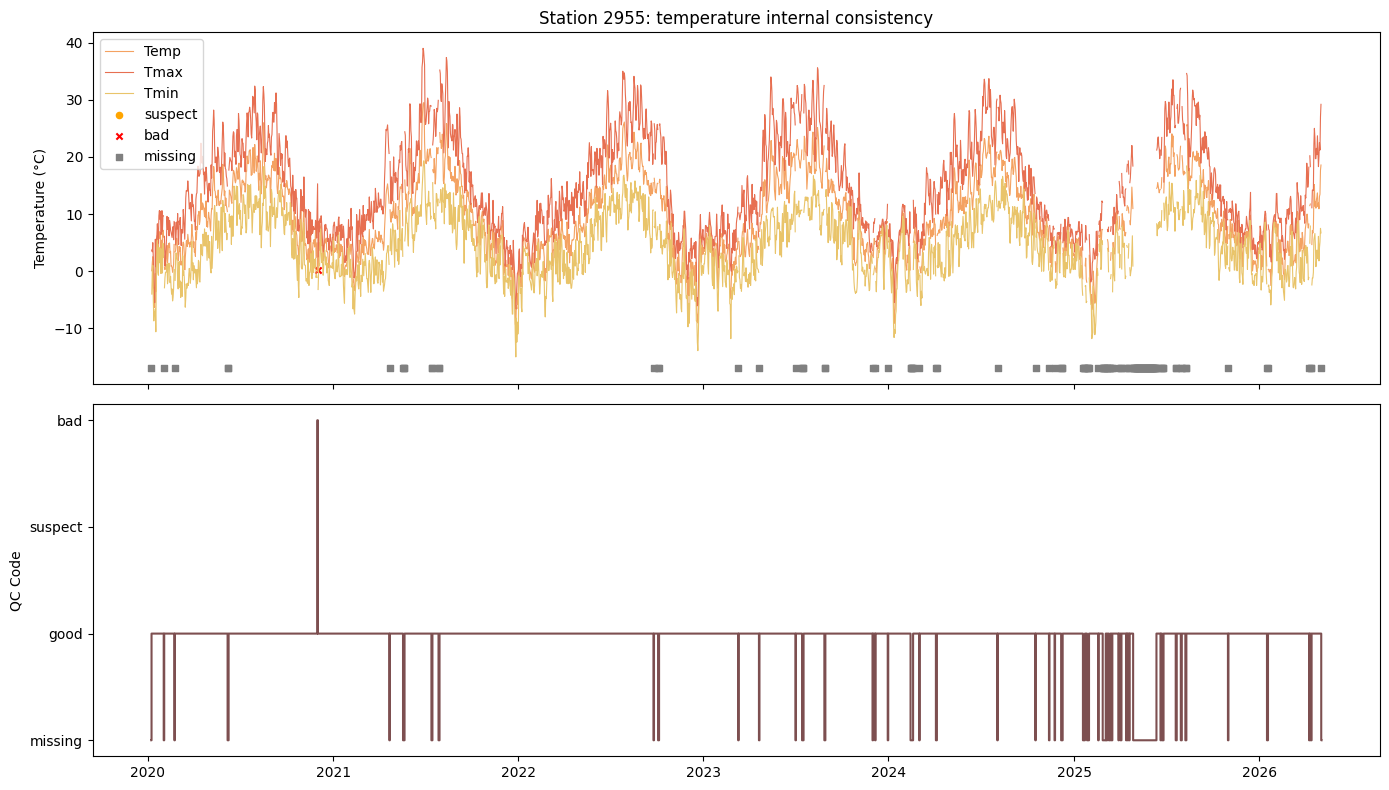

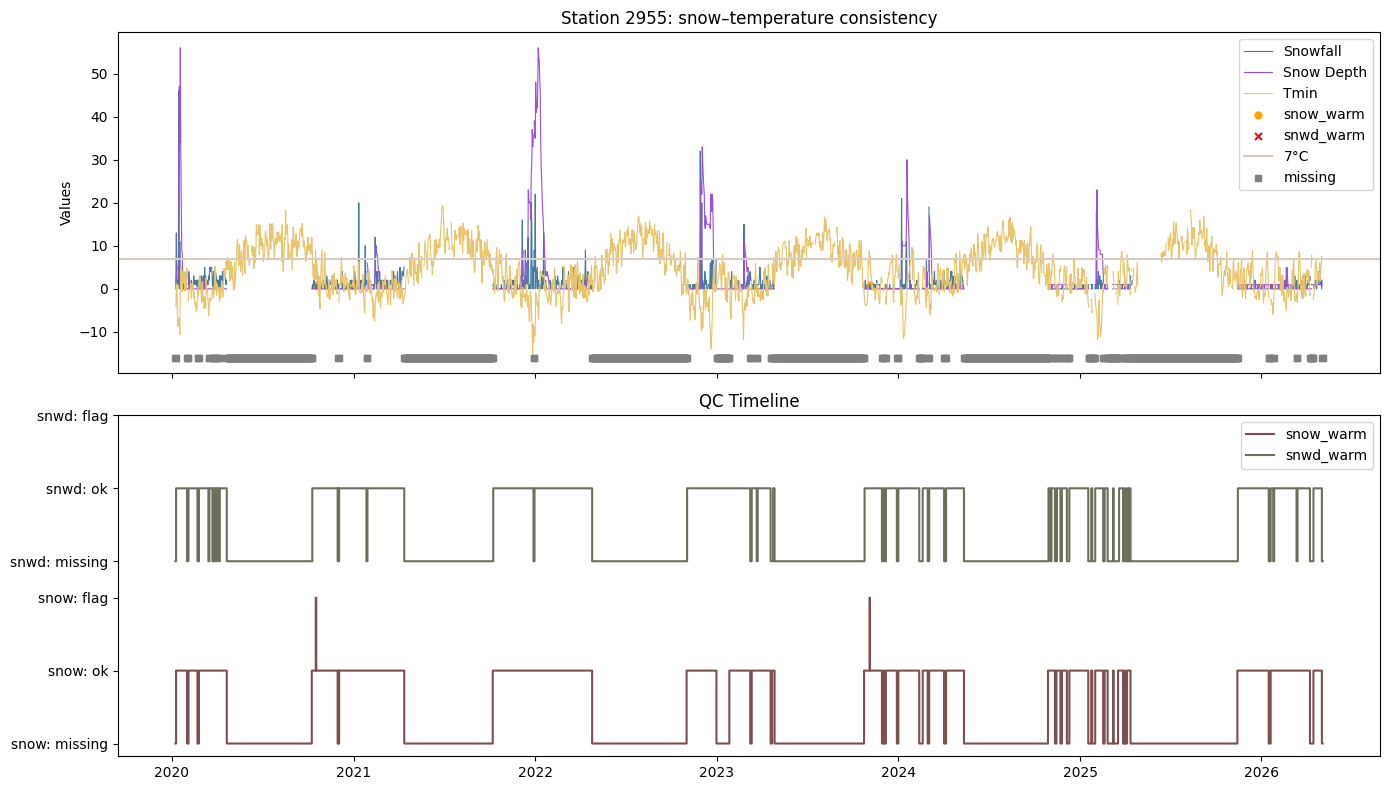

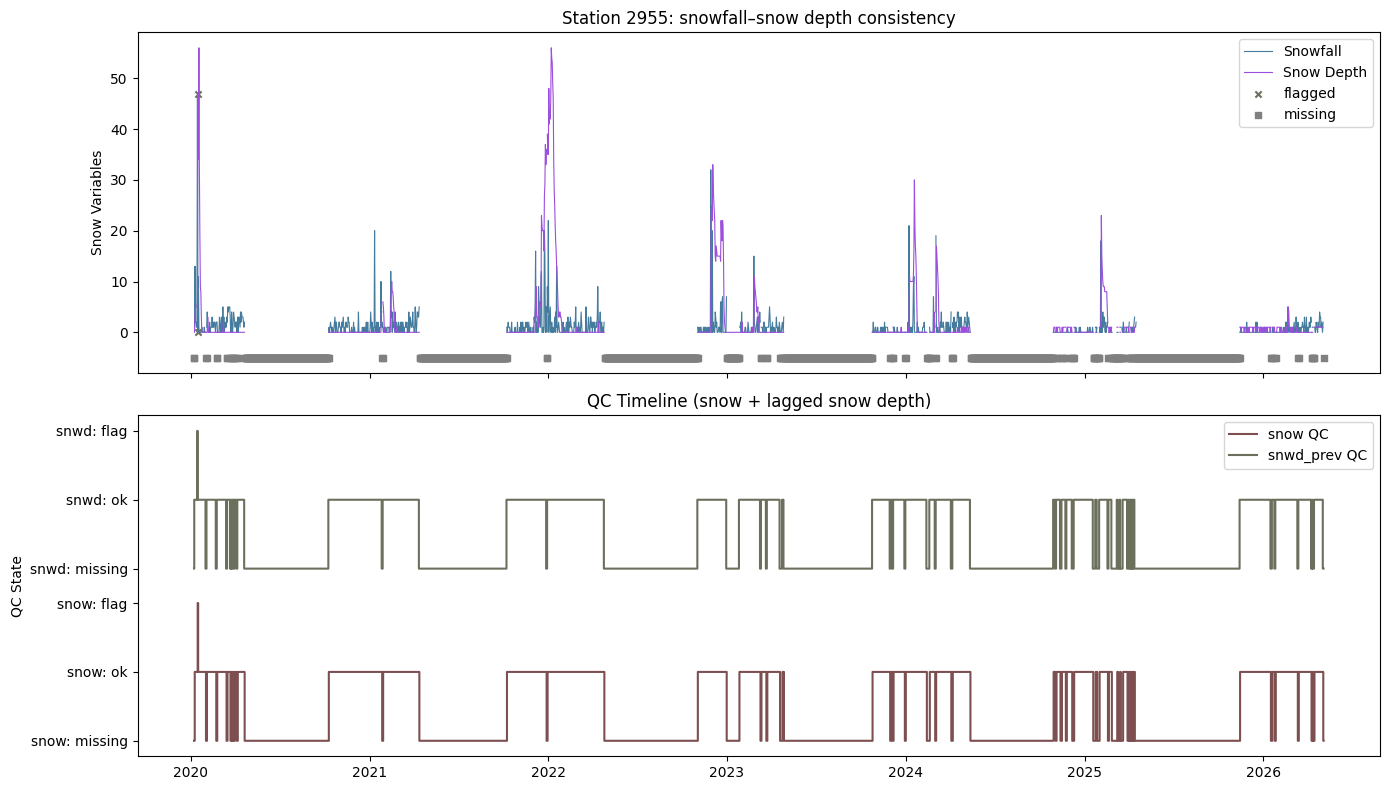

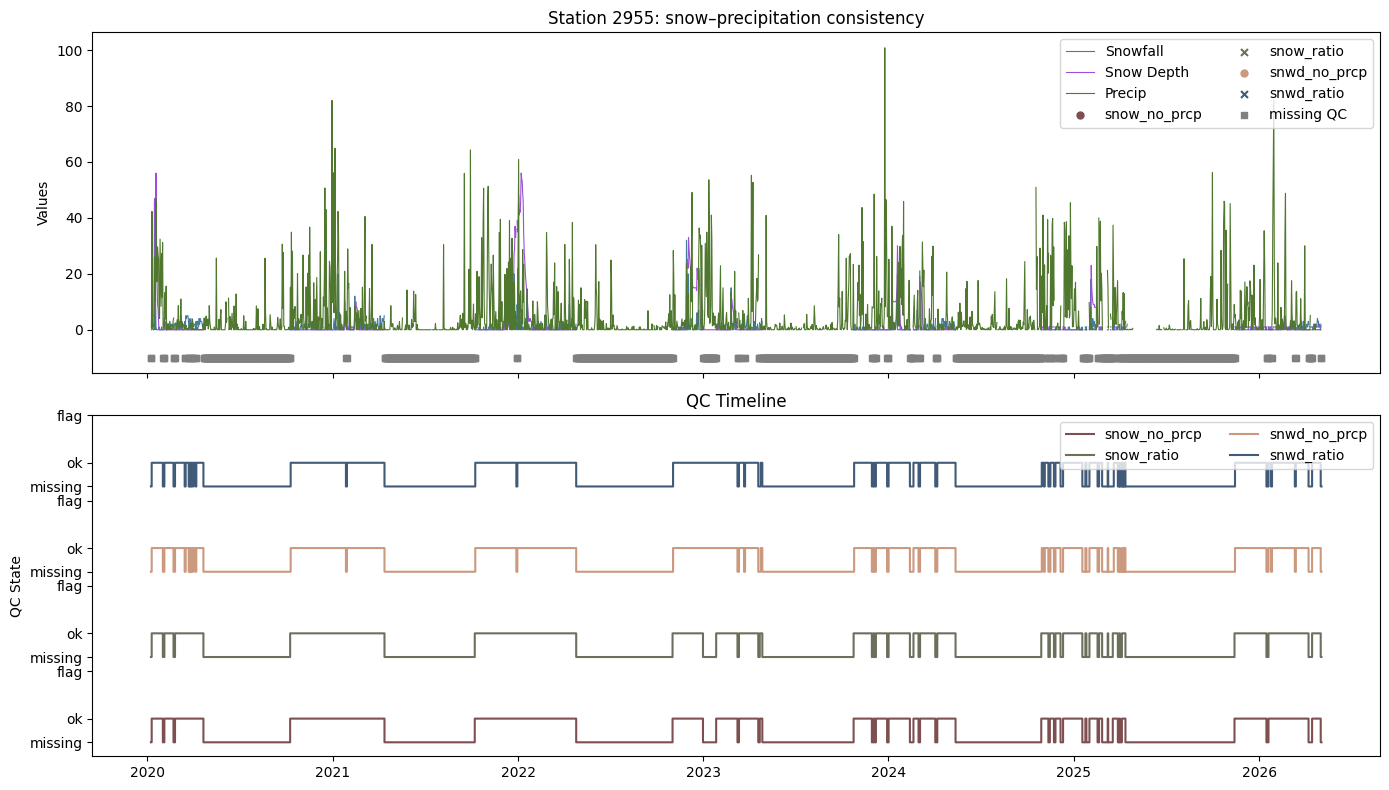

In [32]:
value_cols = ["temp", "tmin", "tmax", "precip", "snw_fall", "snw_dpth"]
color_map = {
    "temp": "#f4a261",
    "tmin": "#e9c46a",
    "tmax": "#e76f51",
    "snw_fall": "#457b9d",
    "snw_dpth": "#9d4edd",
    "precip": "#4f772d",
}

naught_map = {
    "temp": "temp_zero",
    "tmin": "tmin_zero",
    "tmax": "tmax_zero",
    "precip": "precip_trace",
    "snw_fall": "snw_fall_trace",
    "snw_dpth": "snw_dpth_trace",
}

for station_id, df_station in df_obs.groupby("station_id"):
    print("" + "=" * 80)
    print(f"Station {station_id}")
    print("=" * 80)

    daily_all = build_daily_all(df_station)
    result = run_qc_pipeline(daily_all, value_cols)

    print(f"Station Rating: {result['station_rating']}")
    print(f"Recommendation: {result['recommendation']}")
    print("Plotting daily data and QC flag diagnostics...")

    plot_weather_data(
        daily_all,
        color_map=color_map,
        title=f"Station {station_id}: raw daily data"
    )

    plot_timeseries_with_naught_missing_multi(
        df=daily_all,
        color_map=color_map,
        naught_all=result["naught_all"],
        naught_map=naught_map,
        miss_result_dict=result["miss_result_dict"],
        value_cols=value_cols,
        title=f"Station {station_id}: raw daily series with naught + missing flags"
    )

    plot_multi_range_check(
        df=daily_all,
        wmo_rules=result["wmo_rules"],
        range_results=result["range_results"],
        color_map=color_map,
        outrange_scatter_color="#843939",
        title=f"Station {station_id}: WMO Range Check"

    )

    daily_cleaned = result['daily_cleaned']

    plot_weather_data(
        daily_cleaned,
        color_map=color_map,
        title=f"Station {station_id}: cleaned daily data"
    )

    gap_flags = pd.concat(
        {col: res["flag"] for col, res in result["gap_result_dict"].items()},
        axis=1
    ) if result["gap_result_dict"] else pd.DataFrame(index=daily_all.index)

    plot_clim_check_multi(
        df=daily_cleaned,
        color_map=color_map,
        gap_flags=gap_flags,
        clim_flags=result["clim_flag_df"],
        show_gap=True,
        show_clim=True,
        title=f"Station {station_id}: Climatological check (Gap + Climatological)"

    )

    plot_inttemp_tas_timeseries(
        result["inttemp_tas_result"],
        color_map=color_map,
        missing_color="gray",
        state_color="#7d4f50",
        title=f"Station {station_id}: temperature internal consistency"
    )

    plot_inttemp_snow_tmin_timeseries(
        daily_cleaned,
        result["inttemp_snow_tmin_result"],
        color_map=color_map,
        missing_color="gray",
        state_color=["#7d4f50", "#6b705c"],
        title=f"Station {station_id}: snow–temperature consistency"
    )

    plot_inttemp_snow_fall_dpth_timeseries(
        daily_cleaned,
        result["inttemp_snow_fall_dpth_result"],
        color_map=color_map,
        missing_color="gray",
        state_color=["#7d4f50", "#6b705c"],
        title=f"Station {station_id}: snowfall–snow depth consistency"
    )

    plot_inttemp_snow_precip_timeseries(
        daily_cleaned,
        result["inttemp_snow_precip_result"],
        color_map=color_map,
        missing_color="gray",
        state_color=["#7d4f50", "#6b705c", "#cb997e", "#415a77"],
        title=f"Station {station_id}: snow–precipitation consistency"
    )

In [36]:
result["daily_cleaned"]

net_var_name,temp,tmax,tmin,precip,snw_fall,snw_dpth
obs_time,,,,,,
2020-01-08,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-09,0.078261,3.7,-4.0,0.9,1.0,0.0
2020-01-10,1.508333,3.4,-0.1,42.3,13.0,3.0
2020-01-11,2.537500,5.0,1.0,0.5,2.0,5.0
2020-01-12,-0.395833,2.2,-5.1,0.0,2.0,5.0
...,...,...,...,...,...,...
2026-04-30,13.091667,22.5,4.1,0.0,2.0,1.0
2026-05-01,13.483333,21.2,5.1,0.0,1.0,1.0
2026-05-02,17.669565,27.0,7.5,0.0,0.0,1.0


In [42]:
result["daily_cleaned"]

net_var_name,temp,tmax,tmin,precip,snw_fall,snw_dpth
obs_time,,,,,,
2020-01-08,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-09,0.078261,3.7,-4.0,0.9,1.0,0.0
2020-01-10,1.508333,3.4,-0.1,42.3,13.0,3.0
2020-01-11,2.537500,5.0,1.0,0.5,2.0,5.0
2020-01-12,-0.395833,2.2,-5.1,0.0,2.0,5.0
...,...,...,...,...,...,...
2026-04-30,13.091667,22.5,4.1,0.0,2.0,1.0
2026-05-01,13.483333,21.2,5.1,0.0,1.0,1.0
2026-05-02,17.669565,27.0,7.5,0.0,0.0,1.0
